In [1]:
# Cell 1 — Setup & Imports
%pip install --quiet numpy pandas matplotlib seaborn scikit-learn jinja2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Libraries loaded.')

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head()


[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Libraries loaded.


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [2]:
# Cell 2 — Dataset Overview
print('=== SHAPE ===')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')

print('\n=== DATA TYPES ===')
print(df.dtypes.value_counts())

print('\n=== MISSING VALUES ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values found.')

print('\n=== DUPLICATE ROWS ===')
print(f'Duplicates: {df.duplicated().sum()}')

print('\n=== ALL COLUMNS & TYPES ===')
print(df.dtypes.to_string())


=== SHAPE ===
Rows: 1,470  |  Columns: 35

=== DATA TYPES ===
int64    26
str       9
Name: count, dtype: int64

=== MISSING VALUES ===
No missing values found.

=== DUPLICATE ROWS ===
Duplicates: 0

=== ALL COLUMNS & TYPES ===
Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                

In [3]:
# Numerical descriptive statistics
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])
# Categorical descriptive statistics
df.describe(include='object').T

,count,unique,top,freq
Attrition,1470,2,No,1233
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
Over18,1470,1,Y,1470
OverTime,1470,2,No,1054


In [4]:
# Cell 3 — Drop Constant/ID Columns
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df.drop(columns=cols_to_drop, inplace=True)

print(f'Dropped: {cols_to_drop}')
print(f'Remaining shape: {df.shape}')
print(f'Remaining columns ({df.shape[1]}):')
print(df.columns.tolist())


Dropped: ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
Remaining shape: (1470, 31)
Remaining columns (31):
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


           Count  Percentage
Attrition                   
No          1233       83.88
Yes          237       16.12


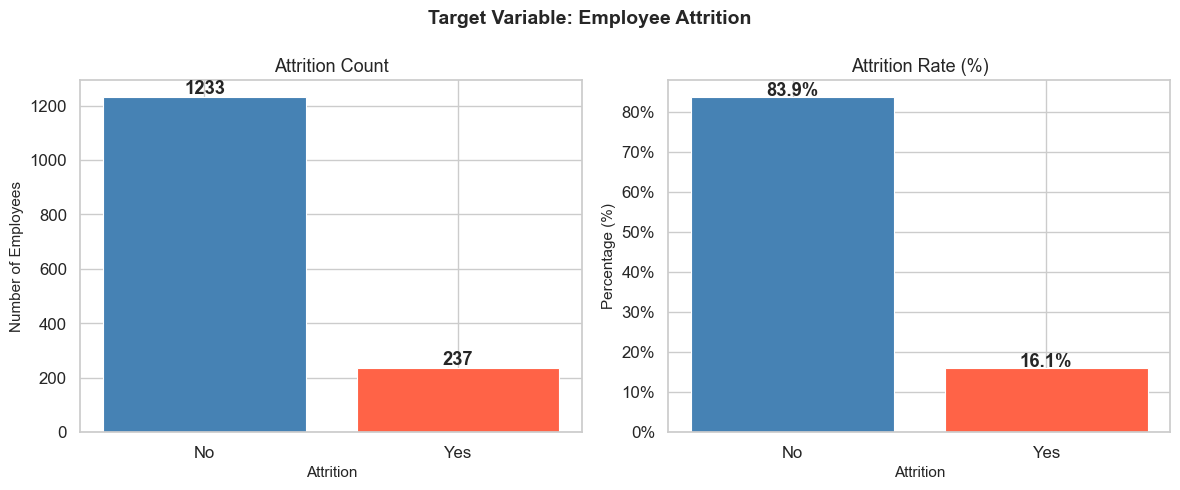

In [5]:
# Cell 4 — Target Variable Analysis
attrition_counts = df['Attrition'].value_counts()
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100

summary = pd.DataFrame({'Count': attrition_counts, 'Percentage': attrition_pct.round(2)})
print(summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(attrition_counts.index, attrition_counts.values,
            color=['steelblue', 'tomato'], edgecolor='white', linewidth=0.8)
axes[0].set_title('Attrition Count')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Number of Employees')
for i, v in enumerate(attrition_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

axes[1].bar(attrition_pct.index, attrition_pct.values,
            color=['steelblue', 'tomato'], edgecolor='white', linewidth=0.8)
axes[1].set_title('Attrition Rate (%)')
axes[1].set_xlabel('Attrition')
axes[1].set_ylabel('Percentage (%)')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
for i, v in enumerate(attrition_pct.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Target Variable: Employee Attrition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


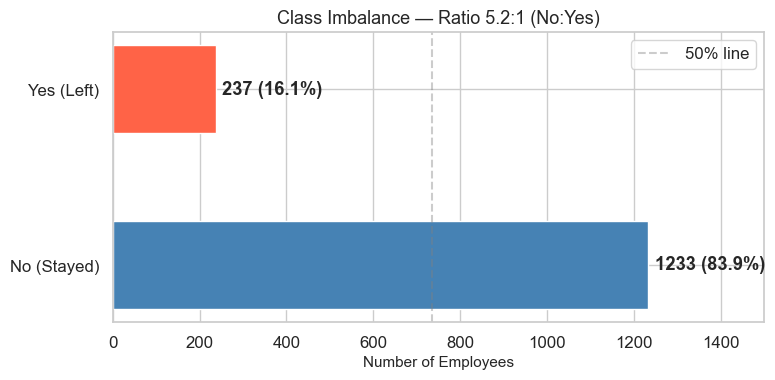

Imbalance ratio: 5.2:1
A model predicting "No" always achieves ~84% accuracy — recall for "Yes" is the priority metric.


In [6]:
# Cell 5 — Class Imbalance Framing
imbalance_ratio = attrition_counts['No'] / attrition_counts['Yes']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(['No (Stayed)', 'Yes (Left)'],
               [attrition_counts['No'], attrition_counts['Yes']],
               color=['steelblue', 'tomato'], height=0.5)

for bar, count in zip(bars, [attrition_counts['No'], attrition_counts['Yes']]):
    ax.text(bar.get_width() + 15, bar.get_y() + bar.get_height() / 2,
            f'{count} ({count / df.shape[0] * 100:.1f}%)', va='center', fontweight='bold')

ax.set_xlabel('Number of Employees')
ax.set_title(f'Class Imbalance — Ratio {imbalance_ratio:.1f}:1 (No:Yes)')
ax.set_xlim(0, 1500)
ax.axvline(x=df.shape[0] * 0.5, color='gray', linestyle='--', alpha=0.4, label='50% line')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Imbalance ratio: {imbalance_ratio:.1f}:1')
print('A model predicting "No" always achieves ~84% accuracy — recall for "Yes" is the priority metric.')


Numerical columns (23): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


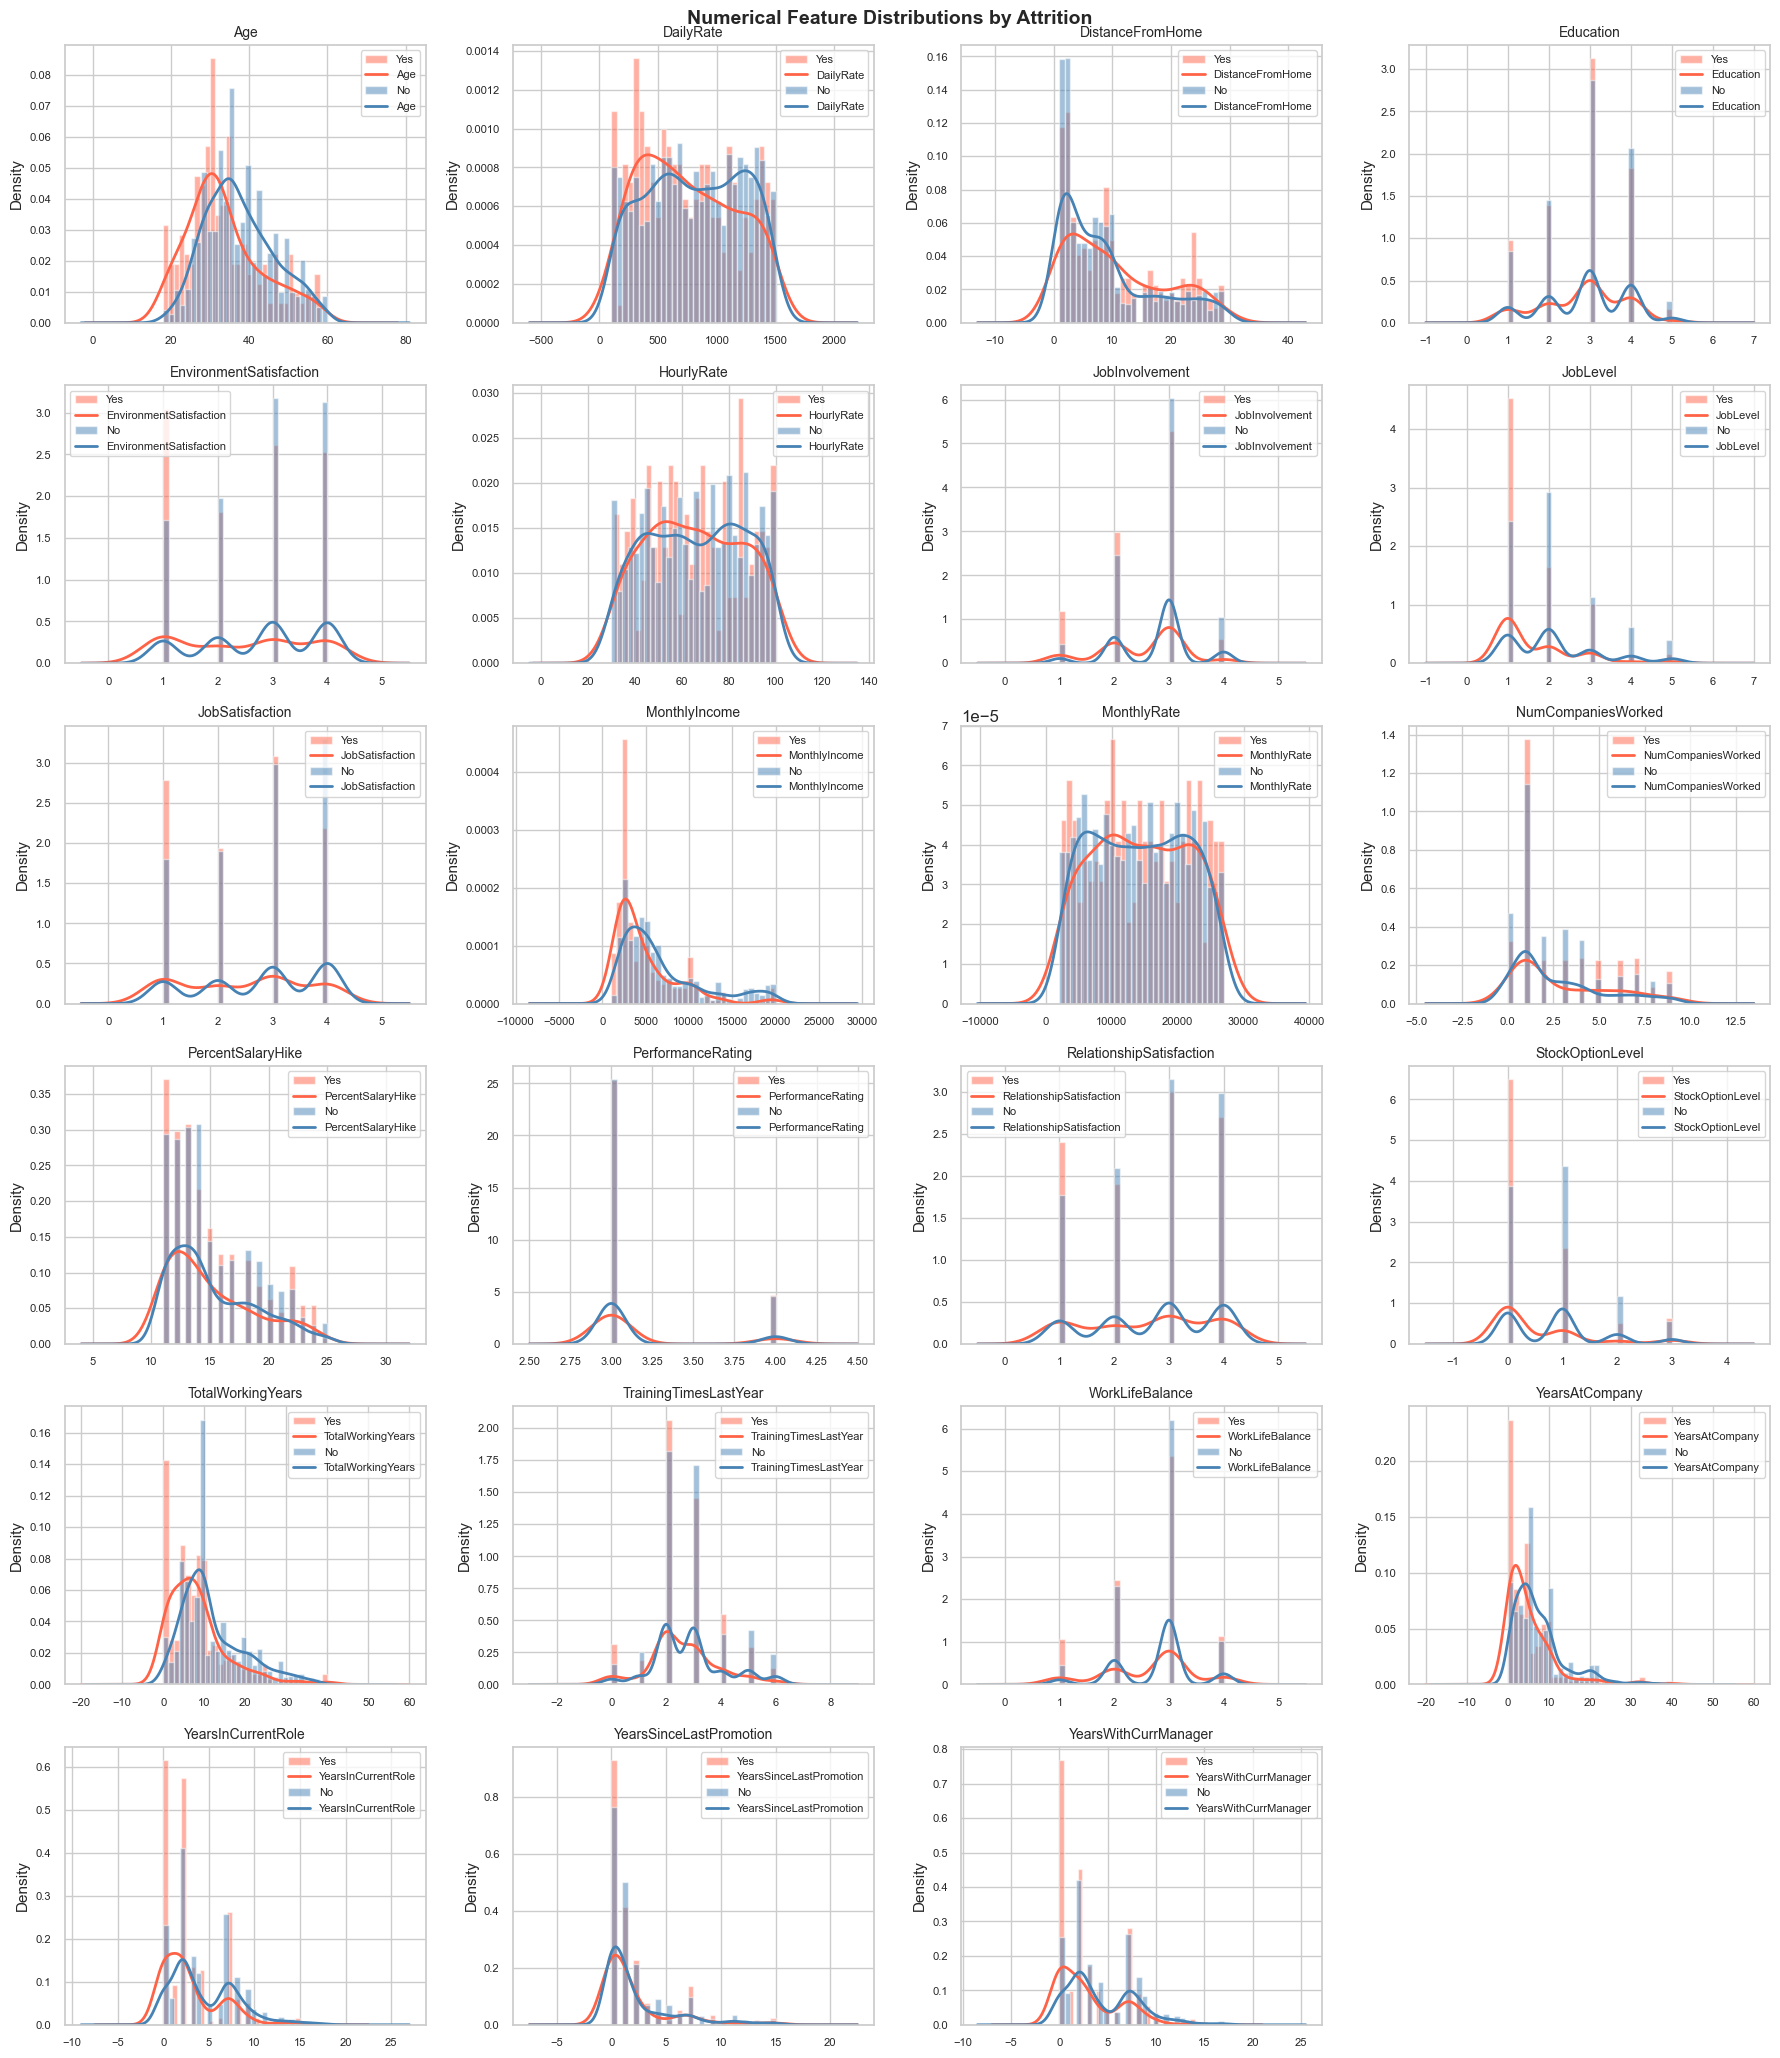

In [7]:
# Cell 6 — Numerical Feature Distributions by Attrition
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f'Numerical columns ({len(numerical_cols)}): {numerical_cols}')

n_cols = 4
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

palette = {'Yes': 'tomato', 'No': 'steelblue'}

for i, col in enumerate(numerical_cols):
    for attrition_val, color in palette.items():
        subset = df[df['Attrition'] == attrition_val][col]
        axes[i].hist(subset, bins=30, alpha=0.5, color=color,
                     label=attrition_val, density=True)
        subset.plot.kde(ax=axes[i], color=color, linewidth=2)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)
    axes[i].tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions by Attrition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


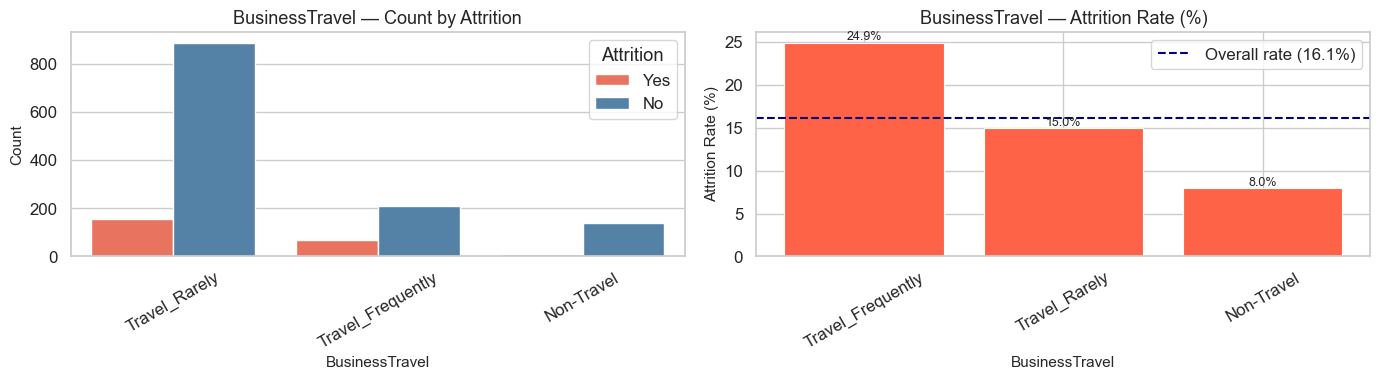

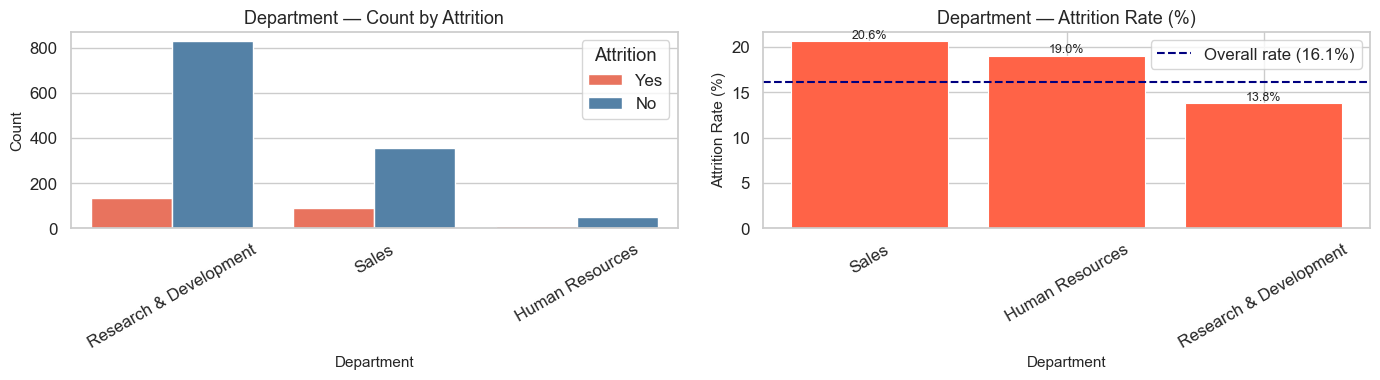

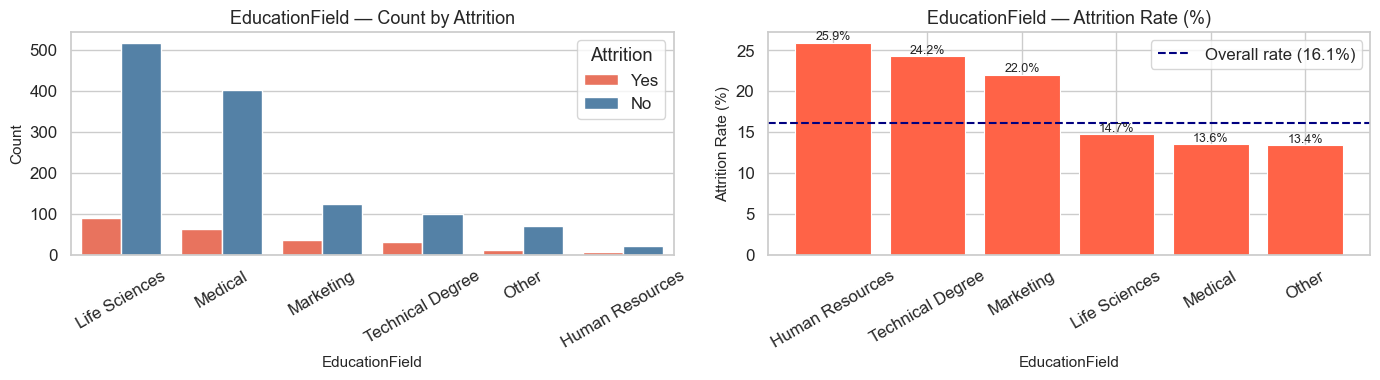

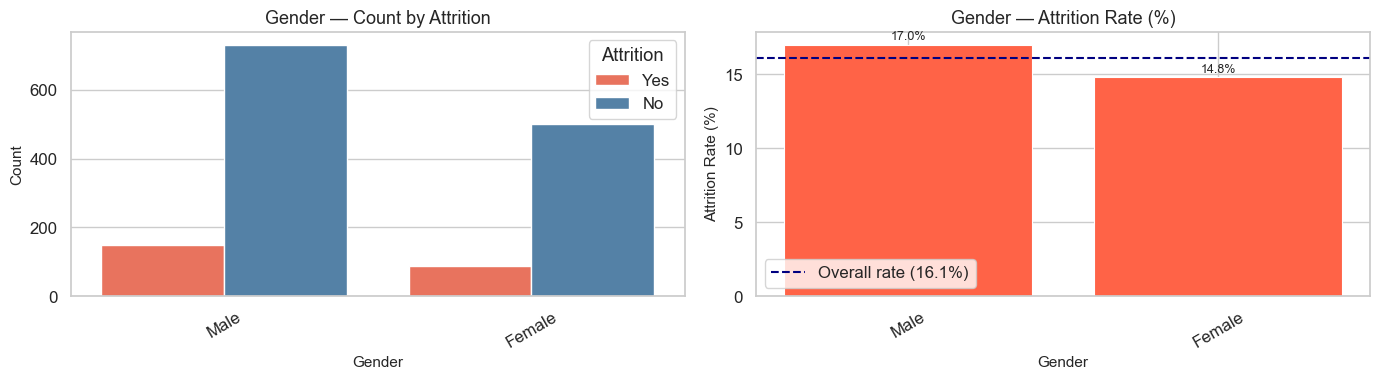

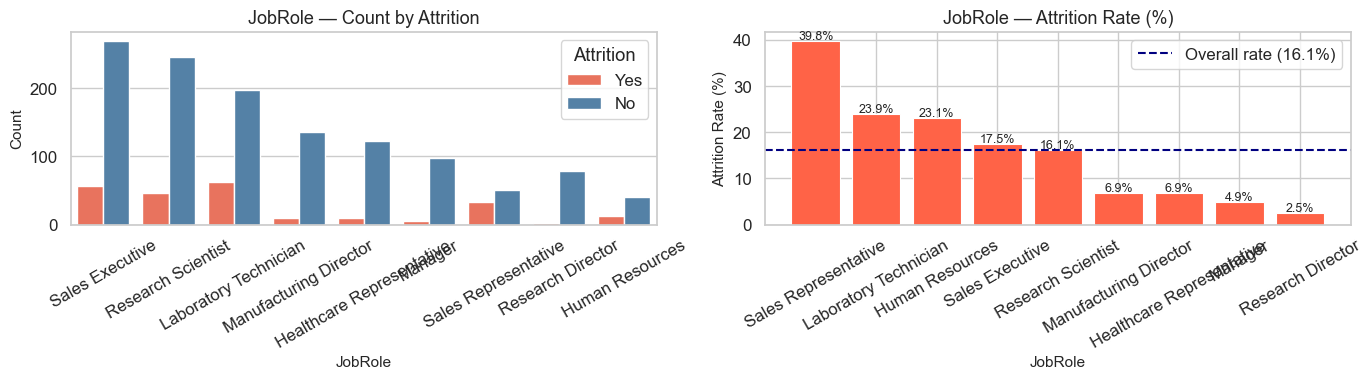

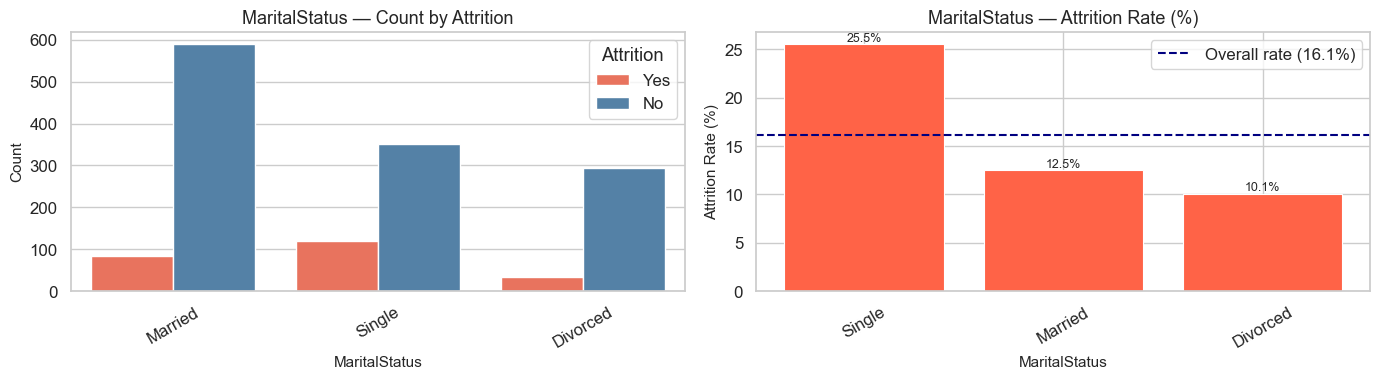

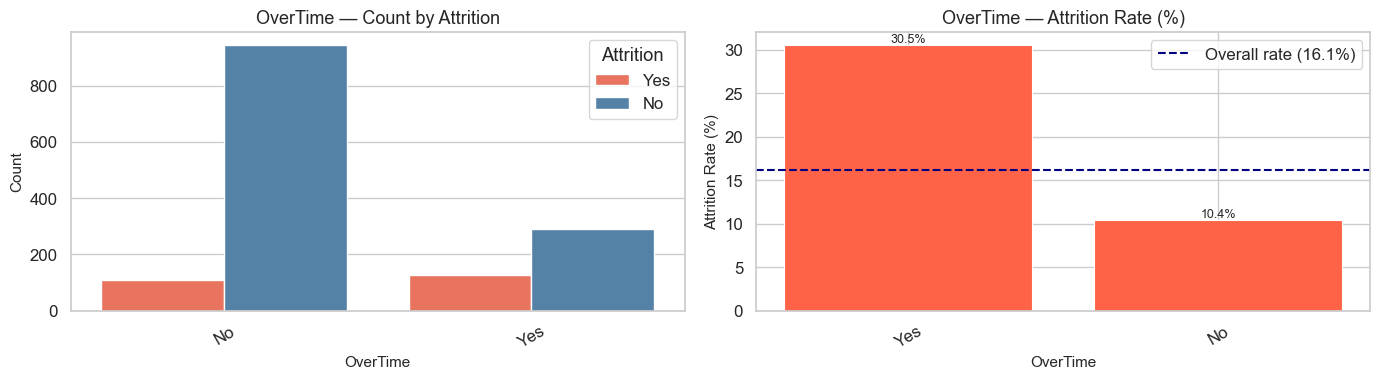

In [8]:
# Cell 7 — Categorical Feature Breakdown by Attrition
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols = [c for c in categorical_cols if c != 'Attrition']
print(f'Categorical columns: {categorical_cols}')

overall_rate = (df['Attrition'] == 'Yes').mean() * 100

for col in categorical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.countplot(data=df, x=col, hue='Attrition', ax=axes[0],
                  palette={'Yes': 'tomato', 'No': 'steelblue'},
                  order=df[col].value_counts().index)
    axes[0].set_title(f'{col} — Count by Attrition')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].legend(title='Attrition')

    rate = df.groupby(col)['Attrition'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).reset_index()
    rate.columns = [col, 'AttritionRate']
    rate = rate.sort_values('AttritionRate', ascending=False)

    bars = axes[1].bar(rate[col], rate['AttritionRate'],
                       color='tomato', edgecolor='white', linewidth=0.8)
    axes[1].axhline(y=overall_rate, color='navy', linestyle='--',
                    linewidth=1.5, label=f'Overall rate ({overall_rate:.1f}%)')
    axes[1].set_title(f'{col} — Attrition Rate (%)')
    axes[1].set_xlabel(col)
    axes[1].set_ylabel('Attrition Rate (%)')
    axes[1].tick_params(axis='x', rotation=30)
    axes[1].legend()
    for bar, val in zip(bars, rate['AttritionRate']):
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                     f'{val:.1f}%', ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()


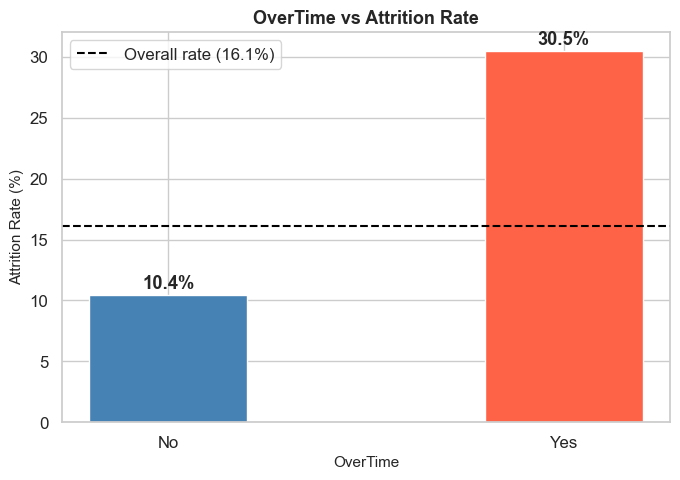

In [9]:
# Cell 8a — OverTime vs Attrition
overall_rate = (df['Attrition'] == 'Yes').mean() * 100

ot_rate = df.groupby('OverTime')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100).reset_index()
ot_rate.columns = ['OverTime', 'AttritionRate']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(ot_rate['OverTime'], ot_rate['AttritionRate'],
              color=['steelblue', 'tomato'], width=0.4, edgecolor='white')
ax.axhline(y=overall_rate, color='black', linestyle='--', label=f'Overall rate ({overall_rate:.1f}%)')
for bar, val in zip(bars, ot_rate['AttritionRate']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold')
ax.set_title('OverTime vs Attrition Rate', fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.set_xlabel('OverTime')
ax.legend()
plt.tight_layout()
plt.show()


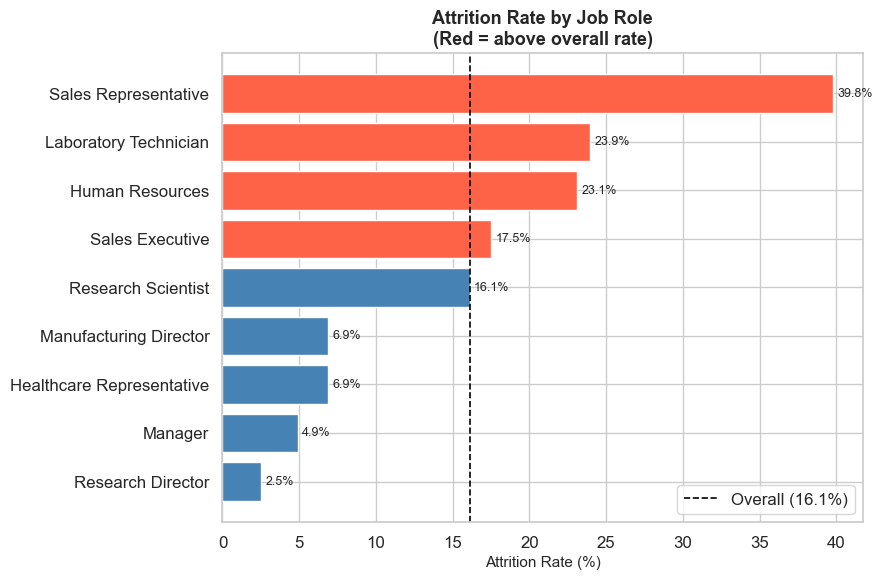

In [10]:
# Cell 8b — JobRole vs Attrition (horizontal bar)
jobrole_rate = df.groupby('JobRole')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['tomato' if v > overall_rate else 'steelblue' for v in jobrole_rate.values]
ax.barh(jobrole_rate.index, jobrole_rate.values, color=colors, edgecolor='white')
ax.axvline(x=overall_rate, color='black', linestyle='--', linewidth=1.2,
           label=f'Overall ({overall_rate:.1f}%)')
for i, val in enumerate(jobrole_rate.values):
    ax.text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Attrition Rate (%)')
ax.set_title('Attrition Rate by Job Role\n(Red = above overall rate)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


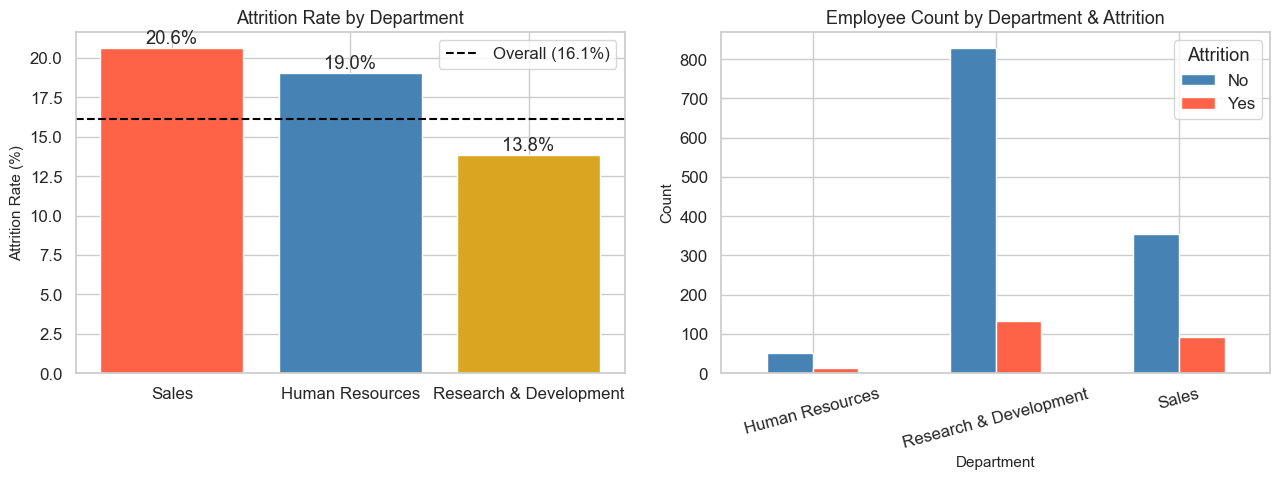

In [11]:
# Cell 8c — Department vs Attrition
dept_rate = df.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False).reset_index()
dept_rate.columns = ['Department', 'AttritionRate']

dept_counts = df.groupby(['Department', 'Attrition']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(dept_rate['Department'], dept_rate['AttritionRate'],
            color=['tomato', 'steelblue', 'goldenrod'], edgecolor='white')
axes[0].axhline(y=overall_rate, color='black', linestyle='--',
                label=f'Overall ({overall_rate:.1f}%)')
axes[0].set_title('Attrition Rate by Department')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].legend()
for i, row in enumerate(dept_rate.itertuples()):
    axes[0].text(i, row.AttritionRate + 0.3, f'{row.AttritionRate:.1f}%', ha='center')

dept_counts.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='white')
axes[1].set_title('Employee Count by Department & Attrition')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Attrition')
plt.tight_layout()
plt.show()


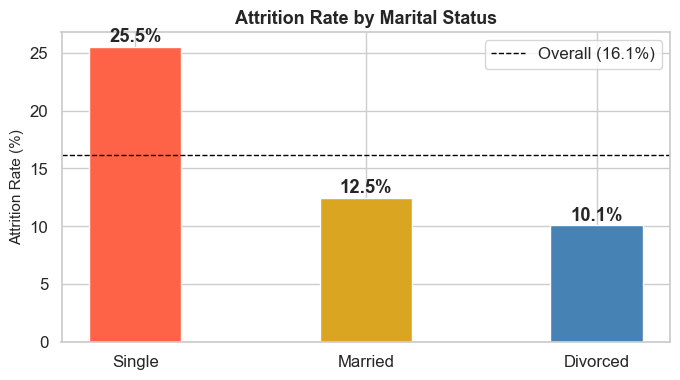

In [12]:
# Cell 8d — MaritalStatus vs Attrition
ms_rate = df.groupby('MaritalStatus')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(ms_rate.index, ms_rate.values,
       color=['tomato', 'goldenrod', 'steelblue'], edgecolor='white', width=0.4)
ax.axhline(y=overall_rate, color='black', linestyle='--',
           linewidth=1, label=f'Overall ({overall_rate:.1f}%)')
for i, val in enumerate(ms_rate.values):
    ax.text(i, val + 0.4, f'{val:.1f}%', ha='center', fontweight='bold')
ax.set_title('Attrition Rate by Marital Status', fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()


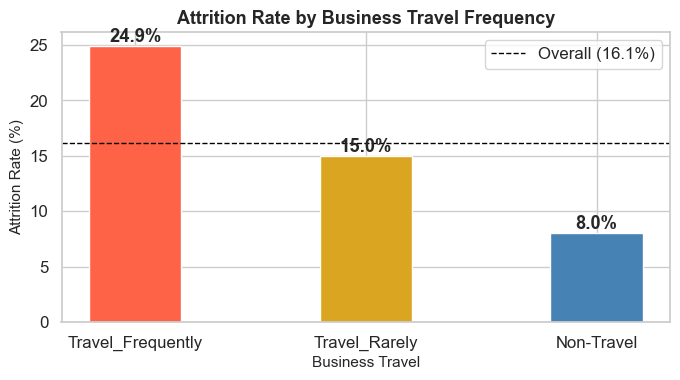

In [13]:
# Cell 8e — BusinessTravel vs Attrition
bt_rate = df.groupby('BusinessTravel')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(bt_rate.index, bt_rate.values,
       color=['tomato', 'goldenrod', 'steelblue'], edgecolor='white', width=0.4)
ax.axhline(y=overall_rate, color='black', linestyle='--',
           linewidth=1, label=f'Overall ({overall_rate:.1f}%)')
for i, val in enumerate(bt_rate.values):
    ax.text(i, val + 0.4, f'{val:.1f}%', ha='center', fontweight='bold')
ax.set_title('Attrition Rate by Business Travel Frequency', fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.set_xlabel('Business Travel')
ax.legend()
plt.tight_layout()
plt.show()


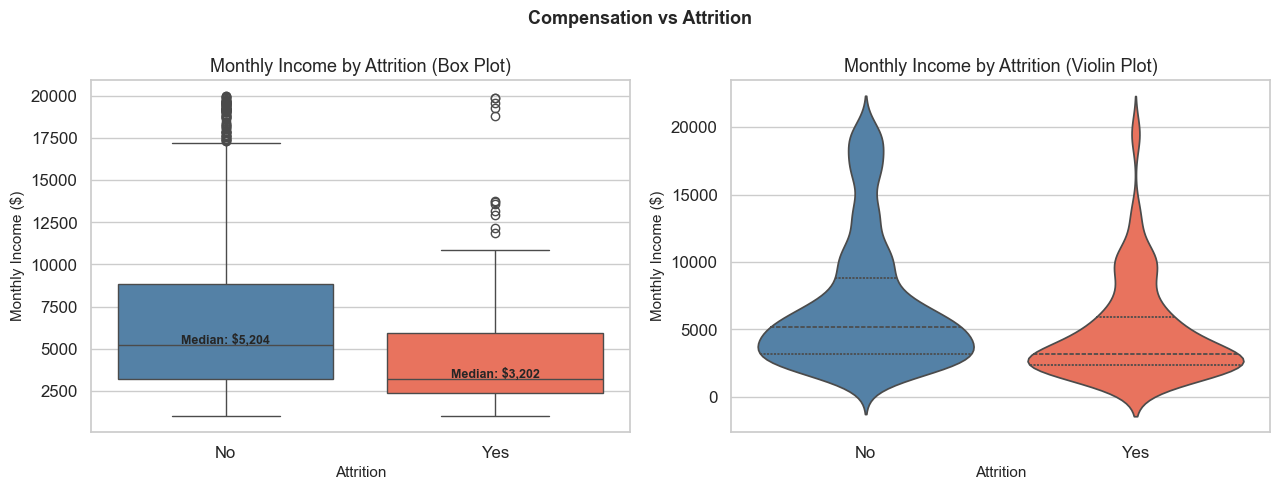

            count    mean     std     min     25%     50%     75%      max
Attrition                                                                 
No        1233.00 6833.00 4818.00 1051.00 3211.00 5204.00 8834.00 19999.00
Yes        237.00 4787.00 3640.00 1009.00 2373.00 3202.00 5916.00 19859.00


In [14]:
# Cell 9 — Compensation Analysis
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', ax=axes[0],
            palette={'Yes': 'tomato', 'No': 'steelblue'}, order=['No', 'Yes'])
axes[0].set_title('Monthly Income by Attrition (Box Plot)')
axes[0].set_ylabel('Monthly Income ($)')
for i, group in enumerate(['No', 'Yes']):
    median = df[df['Attrition'] == group]['MonthlyIncome'].median()
    axes[0].text(i, median + 100, f'Median: ${median:,.0f}',
                 ha='center', fontsize=9, fontweight='bold')

sns.violinplot(data=df, x='Attrition', y='MonthlyIncome', ax=axes[1],
               palette={'Yes': 'tomato', 'No': 'steelblue'},
               order=['No', 'Yes'], inner='quartile')
axes[1].set_title('Monthly Income by Attrition (Violin Plot)')
axes[1].set_ylabel('Monthly Income ($)')

plt.suptitle('Compensation vs Attrition', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(df.groupby('Attrition')['MonthlyIncome'].describe().round(0))


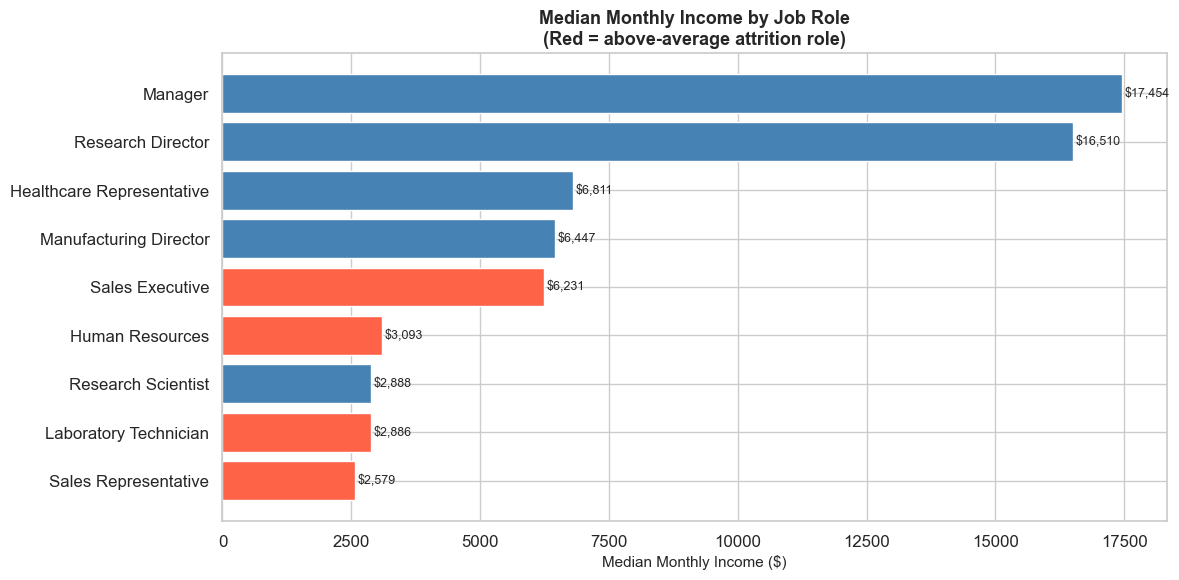

In [15]:
# Monthly income by job role
role_income = df.groupby('JobRole')['MonthlyIncome'].median().sort_values(ascending=True)
high_attrition_roles = jobrole_rate[jobrole_rate > overall_rate].index.tolist()

fig, ax = plt.subplots(figsize=(12, 6))
colors_role = ['tomato' if role in high_attrition_roles else 'steelblue'
               for role in role_income.index]
ax.barh(role_income.index, role_income.values, color=colors_role, edgecolor='white')
ax.set_xlabel('Median Monthly Income ($)')
ax.set_title('Median Monthly Income by Job Role\n(Red = above-average attrition role)', fontweight='bold')
for i, val in enumerate(role_income.values):
    ax.text(val + 50, i, f'${val:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


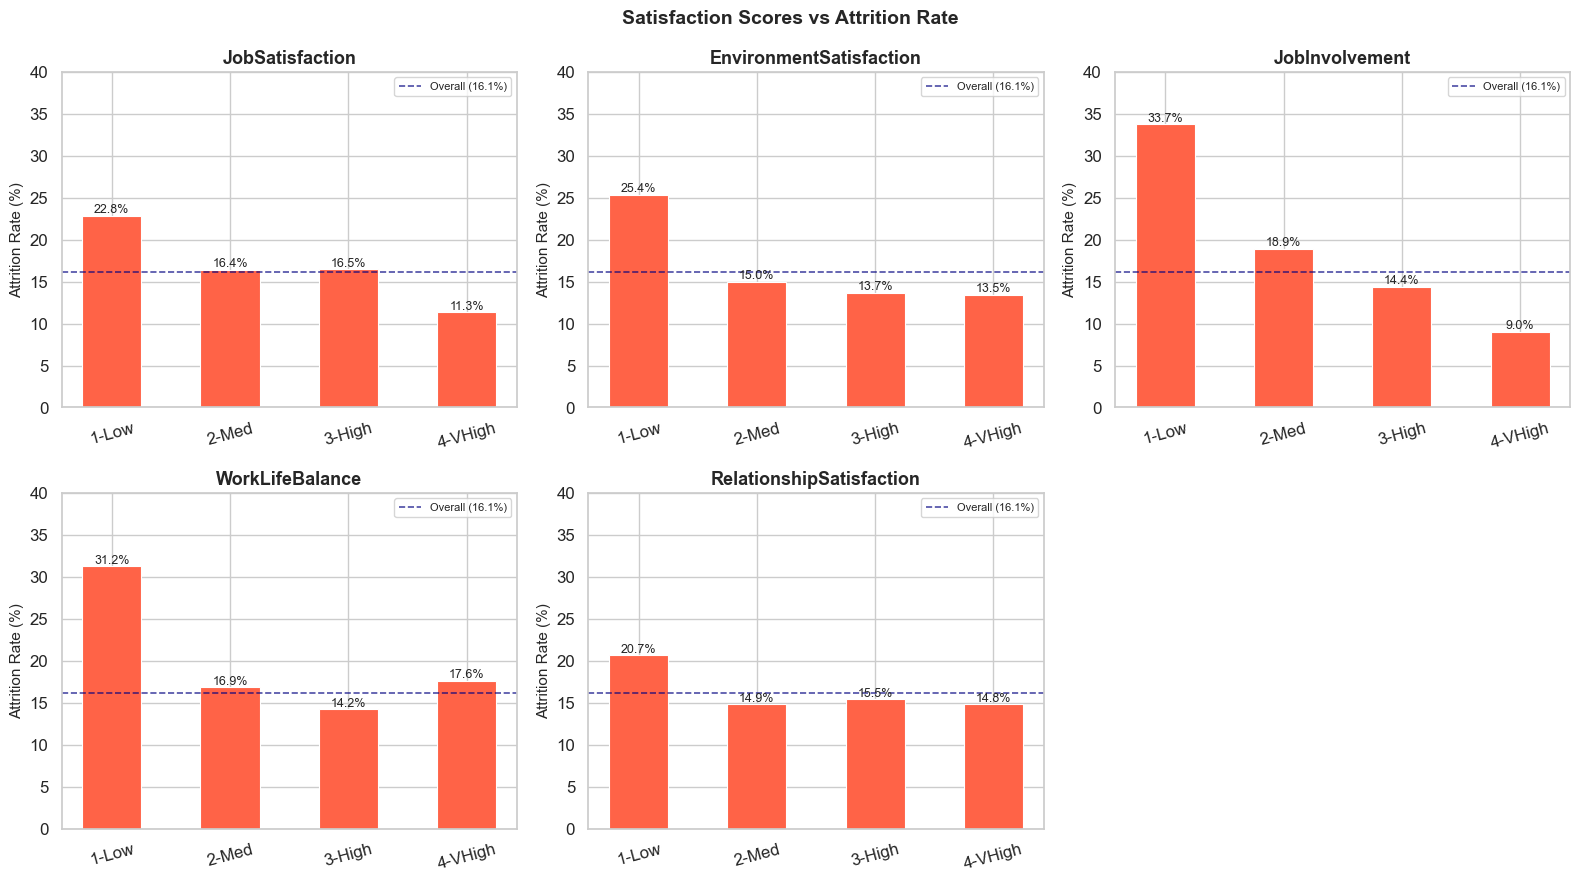

In [16]:
# Cell 10 — Satisfaction Scores Analysis
satisfaction_cols = ['JobSatisfaction', 'EnvironmentSatisfaction',
                     'JobInvolvement', 'WorkLifeBalance', 'RelationshipSatisfaction']

score_labels = {1: '1-Low', 2: '2-Med', 3: '3-High', 4: '4-VHigh'}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(satisfaction_cols):
    rate = df.groupby(col)['Attrition'].apply(
        lambda x: (x == 'Yes').mean() * 100).reset_index()
    rate.columns = [col, 'AttritionRate']
    rate[col] = rate[col].map(score_labels)

    bars = axes[i].bar(rate[col], rate['AttritionRate'],
                       color='tomato', edgecolor='white', linewidth=0.8, width=0.5)
    axes[i].axhline(y=overall_rate, color='navy', linestyle='--', linewidth=1.2,
                    label=f'Overall ({overall_rate:.1f}%)', alpha=0.7)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Attrition Rate (%)')
    axes[i].set_ylim(0, 40)
    axes[i].tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, rate['AttritionRate']):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                     f'{val:.1f}%', ha='center', fontsize=9)
    axes[i].legend(fontsize=8)

axes[5].set_visible(False)

plt.suptitle('Satisfaction Scores vs Attrition Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


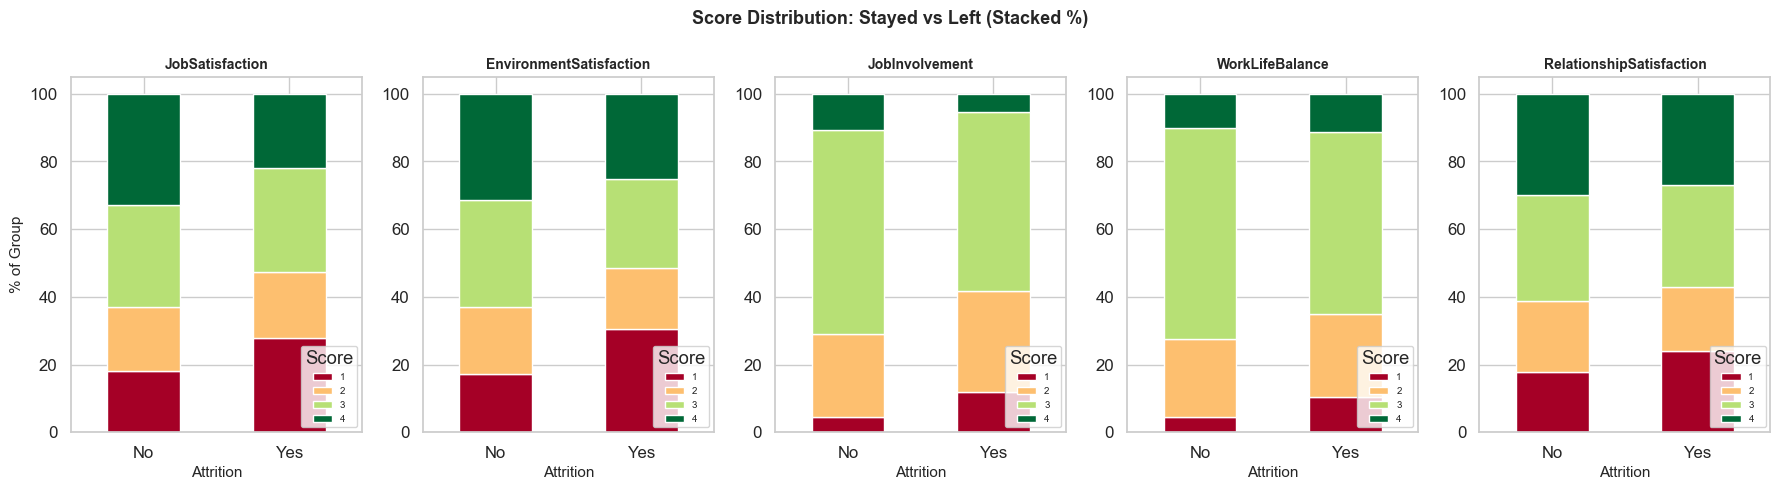

In [17]:
# Score distribution: stayed vs left (stacked %)
fig, axes = plt.subplots(1, len(satisfaction_cols), figsize=(18, 5))

for i, col in enumerate(satisfaction_cols):
    cross = pd.crosstab(df['Attrition'], df[col], normalize='index') * 100
    cross.plot(kind='bar', stacked=True, ax=axes[i],
               colormap='RdYlGn', edgecolor='white')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Attrition')
    axes[i].set_ylabel('% of Group' if i == 0 else '')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title='Score', fontsize=7, loc='lower right')

plt.suptitle('Score Distribution: Stayed vs Left (Stacked %)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


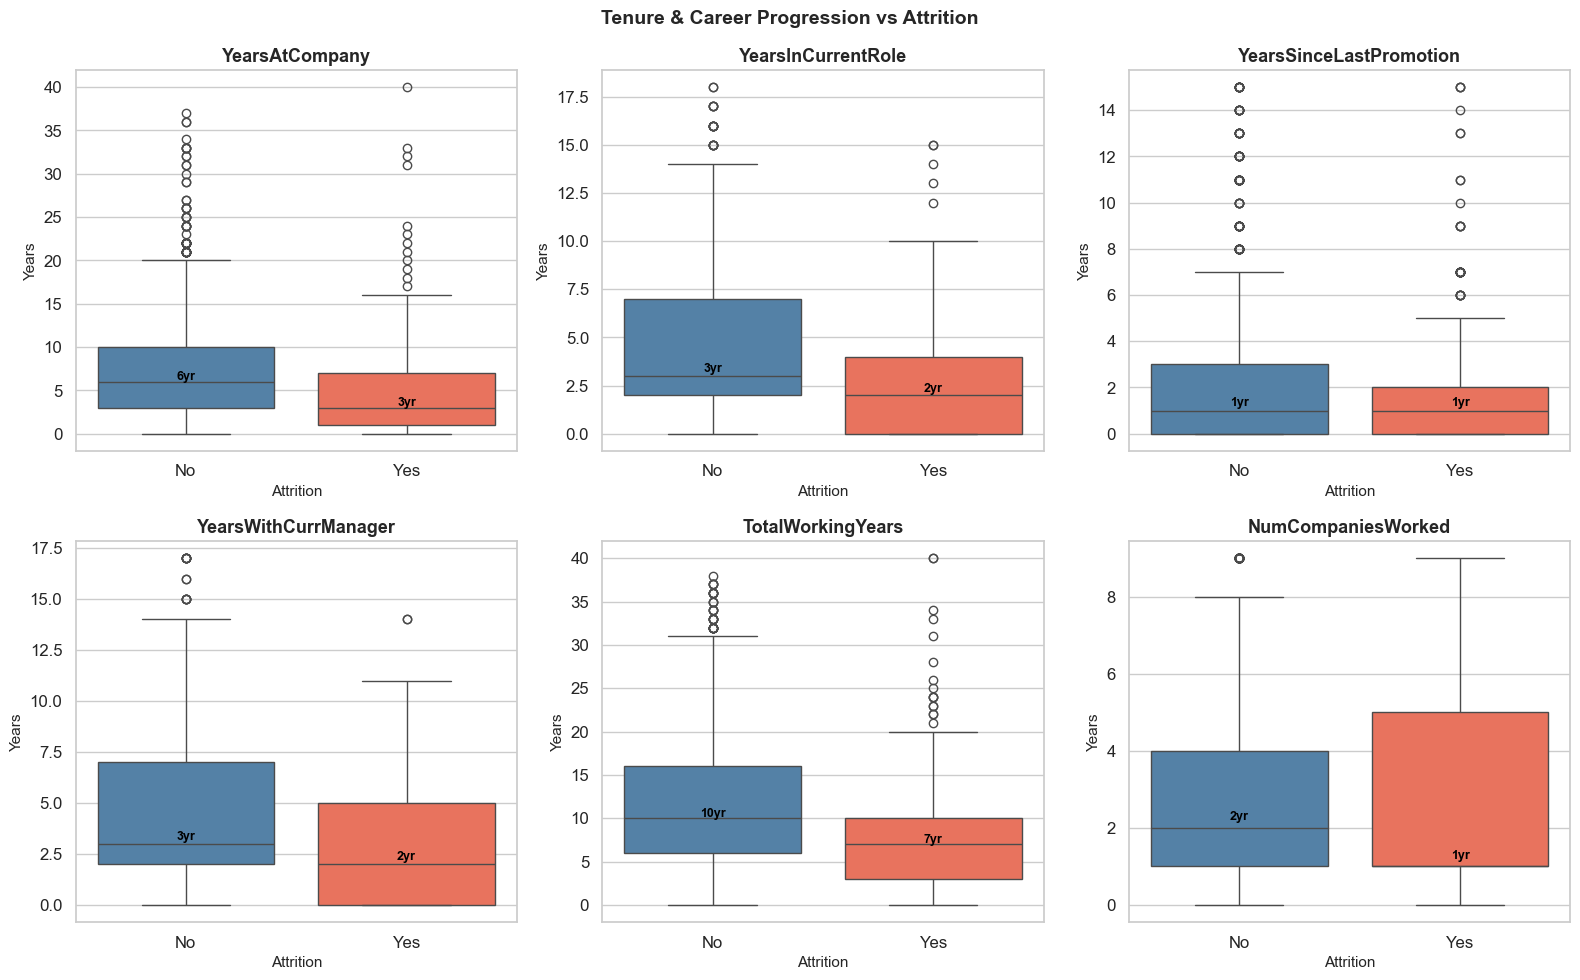

In [18]:
# Cell 11 — Tenure & Career Progression
tenure_cols = ['YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
               'YearsWithCurrManager', 'TotalWorkingYears', 'NumCompaniesWorked']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(tenure_cols):
    sns.boxplot(data=df, x='Attrition', y=col, ax=axes[i],
                palette={'Yes': 'tomato', 'No': 'steelblue'}, order=['No', 'Yes'])
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Attrition')
    axes[i].set_ylabel('Years')
    for j, group in enumerate(['No', 'Yes']):
        med = df[df['Attrition'] == group][col].median()
        axes[i].text(j, med + 0.2, f'{med:.0f}yr', ha='center', fontsize=9,
                     color='black', fontweight='bold')

plt.suptitle('Tenure & Career Progression vs Attrition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


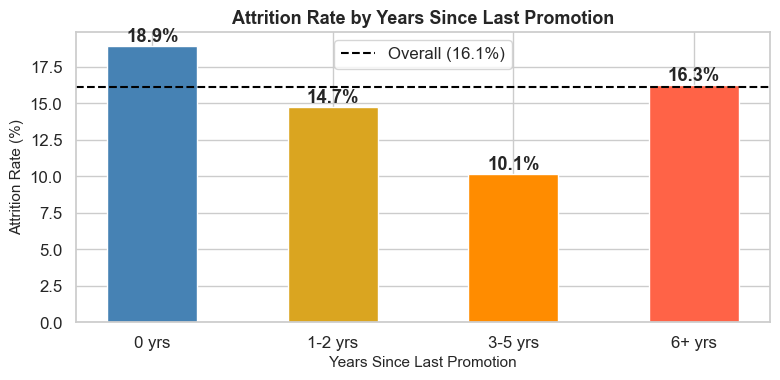

In [19]:
# Binned promotion stagnation analysis
df['PromoBucket'] = pd.cut(df['YearsSinceLastPromotion'],
                           bins=[-1, 0, 2, 5, 100],
                           labels=['0 yrs', '1-2 yrs', '3-5 yrs', '6+ yrs'])

promo_rate = df.groupby('PromoBucket', observed=True)['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(promo_rate.index.astype(str), promo_rate.values,
       color=['steelblue', 'goldenrod', 'darkorange', 'tomato'],
       edgecolor='white', width=0.5)
ax.axhline(y=overall_rate, color='black', linestyle='--',
           label=f'Overall ({overall_rate:.1f}%)')
ax.set_title('Attrition Rate by Years Since Last Promotion', fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.set_xlabel('Years Since Last Promotion')
for i, val in enumerate(promo_rate.values):
    ax.text(i, val + 0.3, f'{val:.1f}%', ha='center', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

df.drop(columns='PromoBucket', inplace=True)


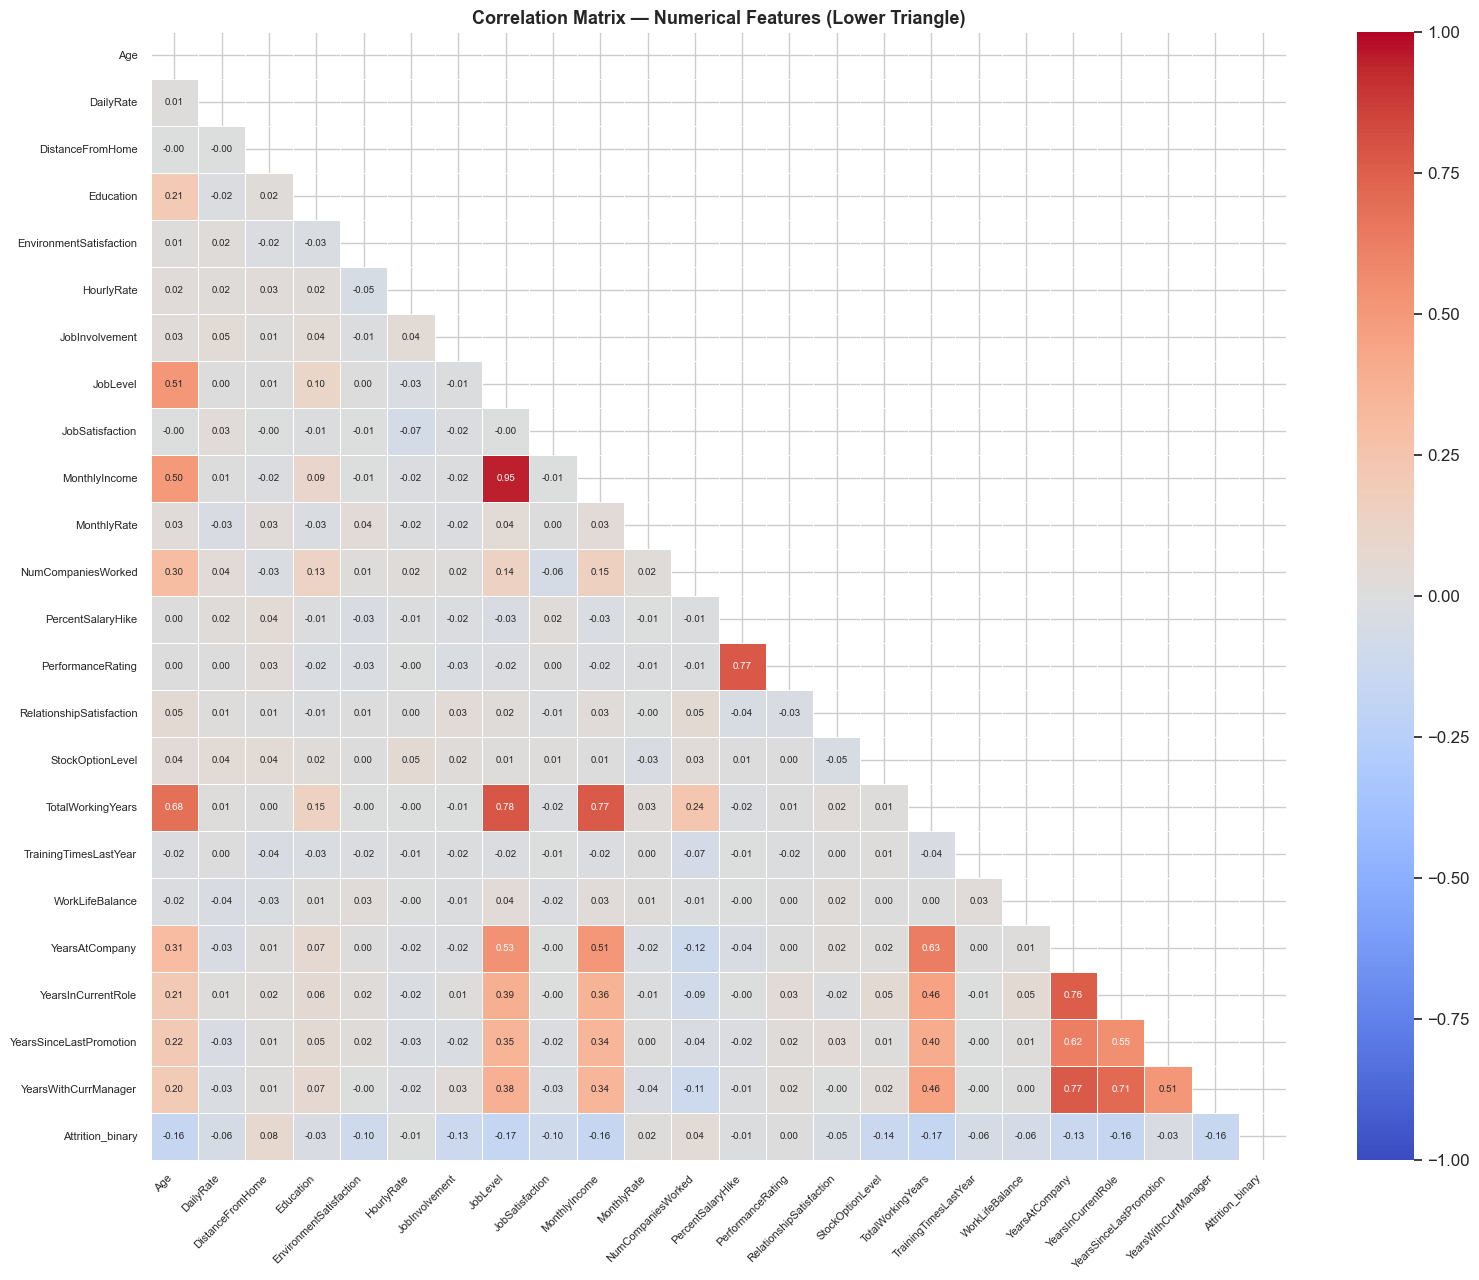

In [20]:
# Cell 12 — Correlation Heatmap
df_corr = df.copy()
df_corr['Attrition_binary'] = (df_corr['Attrition'] == 'Yes').astype(int)
df_corr.drop(columns=['Attrition'], inplace=True)

# Drop remaining categorical columns for pure numeric correlation
num_df = df_corr.select_dtypes(include=['int64', 'float64'])
corr_matrix = num_df.corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.4, linecolor='white',
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Correlation Matrix — Numerical Features (Lower Triangle)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()


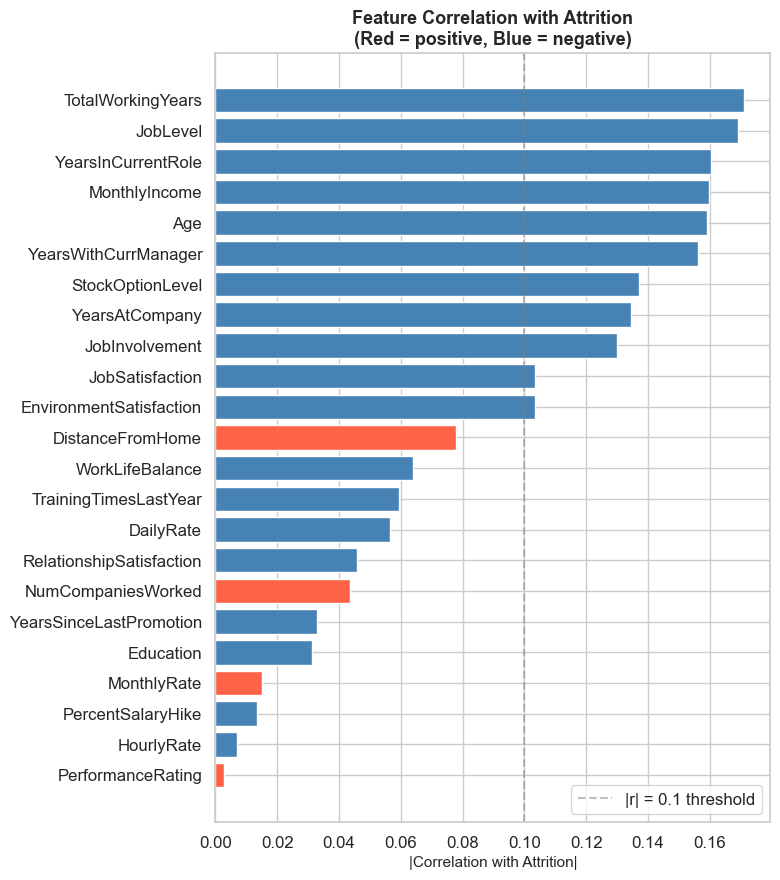

In [21]:
# Feature correlations with Attrition (sorted by absolute value)
attrition_corr = corr_matrix['Attrition_binary'].drop('Attrition_binary')
attrition_corr_sorted = attrition_corr.abs().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 9))
colors = ['tomato' if attrition_corr[col] > 0 else 'steelblue'
          for col in attrition_corr_sorted.index]
ax.barh(attrition_corr_sorted.index, attrition_corr_sorted.values,
        color=colors, edgecolor='white')
ax.set_xlabel('|Correlation with Attrition|')
ax.set_title('Feature Correlation with Attrition\n(Red = positive, Blue = negative)',
             fontweight='bold')
ax.axvline(x=0.1, color='gray', linestyle='--', alpha=0.5, label='|r| = 0.1 threshold')
ax.legend()
plt.tight_layout()
plt.show()


## Key EDA Findings — IBM HR Attrition Dataset

### Dataset
- 1,470 employees, 35 original columns → 31 after dropping constants (`EmployeeCount`, `EmployeeNumber`, `Over18`, `StandardHours`)
- No missing values or duplicates
- Target: **Attrition = Yes (~16%)** vs **No (~84%)** — imbalanced ~5.2:1

### Top Attrition Drivers

| Factor | Observation |
|--------|-------------|
| **OverTime** | Employees doing overtime leave at ~30% vs ~10% — strongest single signal |
| **JobRole** | Sales Representatives and Lab Technicians have highest rates |
| **MaritalStatus** | Single employees leave at ~25%, vs ~12% Married |
| **BusinessTravel** | Frequent travelers leave at ~25%, Non-Travel at ~8% |
| **MonthlyIncome** | Median income of leavers is significantly lower |
| **JobInvolvement** | Score=1 (Low) employees leave at ~33% |
| **WorkLifeBalance** | Score=1 (Low) employees leave at ~31% |
| **YearsAtCompany** | Leavers have shorter median tenure — early attrition is dominant |
| **YearsSinceLastPromotion** | Non-linear: both 0 yrs and 6+ yrs show elevated rates |

### Multicollinearity Flags (for modeling)
- `YearsAtCompany`, `TotalWorkingYears`, `YearsInCurrentRole`, `YearsWithCurrManager` are highly intercorrelated
- `MonthlyIncome` is strongly correlated with `JobLevel` and `TotalWorkingYears`
- Consider feature selection or PCA before training

### Modeling Implications
- **Do not use accuracy** — 84% achievable by predicting "No" always
- **Priority metrics:** Recall (Yes), F1 (Yes), ROC-AUC, PR-AUC
- **Class imbalance handling:** SMOTE, `class_weight='balanced'`, or threshold tuning
- **High-signal features:** `OverTime`, `MonthlyIncome`, `JobRole`, `JobInvolvement`, `MaritalStatus`, `YearsAtCompany`, `WorkLifeBalance`, `BusinessTravel`


## Phase 2 — Preprocessing

In [22]:
# Cell B — Encode target variable
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

X = df.drop(columns=['Attrition'])
y = df['Attrition']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Attrition rate: {y.mean():.1%}')

X shape: (1470, 30)
y shape: (1470,)
Attrition rate: 16.1%


## Phase 3 — Feature Engineering

Engineering new features from the raw columns to improve predictive power, especially recall on the minority attrition class. Three insertion points are used:

| Cell | Position | Purpose |
|------|----------|---------|
| **FE0** | After Cell B, before Cell C | String-based interactions (BusinessTravel, MaritalStatus, OverTime as raw strings) |
| **FE1** | After Cell C, before Cell D | All row-level ratio/composite/flag features (OverTime already binary 0/1) |
| **FE2** | After Cell F, before Cell G | Post-split features requiring train-only statistics (income threshold, peer income) |

In [23]:
# Cell FE0 — Pre-encoding string-based features
# Must run BEFORE Cell C (binary encoding) and Cell E (one-hot encoding).

# Store raw JobRole before one-hot encoding — needed for peer income calculation post-split
X['JobRole_raw'] = X['JobRole']

# G4-I3: Frequent Travel × Poor Work-Life Balance
# Frequent travelers with bad WLB leave at 46.2% — nearly 3× the overall rate
X['FreqTravel_LowWLB'] = (
    (X['BusinessTravel'] == 'Travel_Frequently') &
    (X['WorkLifeBalance'] == 1)
).astype(int)

# G4-I4: Single × OverTime
# Single employees doing overtime leave at 49.6%; OverTime still string 'Yes'/'No' here
X['Single_OT'] = (
    (X['MaritalStatus'] == 'Single').astype(int) *
    (X['OverTime'] == 'Yes').astype(int)
)

print(f'Pre-encoding features added. Shape: {X.shape}')
print(f'FreqTravel_LowWLB: {X["FreqTravel_LowWLB"].sum()} employees in high-risk travel segment')
print(f'Single_OT:         {X["Single_OT"].sum()} single employees working overtime')

Pre-encoding features added. Shape: (1470, 33)
FreqTravel_LowWLB: 13 employees in high-risk travel segment
Single_OT:         131 single employees working overtime


In [24]:
# Cell C — Encode binary categoricals
X['Gender'] = X['Gender'].map({'Female': 0, 'Male': 1})
X['OverTime'] = X['OverTime'].map({'No': 0, 'Yes': 1})

print('Gender and OverTime encoded.')
print(X[['Gender', 'OverTime']].value_counts().sort_index())

Gender and OverTime encoded.
Gender  OverTime
0       0           408
        1           180
1       0           646
        1           236
Name: count, dtype: int64


In [25]:
# Cell FE1 — Row-level engineered features
# Must run AFTER Cell C (OverTime is now binary 0/1) and BEFORE Cell D (BusinessTravel still numeric-safe).

# ── Group 1: Compensation ─────────────────────────────────────────────────────
# Pay fairness within seniority band; leavers earn ~8% less per level than stayers
X['IncomePerLevel'] = X['MonthlyIncome'] / X['JobLevel']

# Combined compensation score — salary + equity (StockOptionLevel) + raise trajectory
X['CompensationScore'] = (
    X['MonthlyIncome'] +
    (X['StockOptionLevel'] * 2000) +
    (X['PercentSalaryHike'] * 100)
)

# Whether income has kept pace with career experience
X['IncomeVsExperience'] = X['MonthlyIncome'] / (X['TotalWorkingYears'] + 1)

# Administrative rate discrepancy (low-confidence — drop if near-zero feature importance)
X['RateDiscrepancy'] = abs(X['DailyRate'] * 22 - X['MonthlyRate']) / (X['MonthlyRate'] + 1)

# ── Group 2: Tenure & Career ──────────────────────────────────────────────────
# Fraction of career spent at this company; median 0.50 (leavers) vs 0.67 (stayers)
X['TenureRatio'] = X['YearsAtCompany'] / (X['TotalWorkingYears'] + 1)

# Contextualises promotion stagnation relative to tenure
X['PromotionStagnationRatio'] = X['YearsSinceLastPromotion'] / (X['YearsAtCompany'] + 1)

# Role stability; corr with attrition −0.158 — stable roles reduce attrition
X['RoleStability'] = X['YearsInCurrentRole'] / (X['YearsAtCompany'] + 1)

# Manager relationship stability; "people leave managers, not companies"
X['ManagerStability'] = X['YearsWithCurrManager'] / (X['YearsAtCompany'] + 1)

# Job-hopping normalised for career stage; leavers median 0.33 vs stayers 0.17
X['JobHoppingIndex'] = X['NumCompaniesWorked'] / (X['TotalWorkingYears'] + 1)

# ── Group 3: Satisfaction Composites ─────────────────────────────────────────
# Overall wellbeing index; corr with attrition −0.159 — stronger than any single component
X['SatisfactionComposite'] = (
    X['JobSatisfaction'] + X['EnvironmentSatisfaction'] +
    X['RelationshipSatisfaction'] + X['WorkLifeBalance']
) / 4

# Work engagement (absorption in + satisfaction with the job); JobInvolvement=1 → 33% attrition
X['EngagementScore'] = (X['JobInvolvement'] + X['JobSatisfaction']) / 2

# Environmental & relational wellbeing — push factors distinct from job content
X['WellbeingScore'] = (
    X['WorkLifeBalance'] + X['RelationshipSatisfaction'] +
    X['EnvironmentSatisfaction']
) / 3

# ── Group 4: Interaction Features ────────────────────────────────────────────
# Overworked + unrewarding work: 36.6% attrition vs 13.7% overall
X['OT_LowJobSat'] = X['OverTime'] * (X['JobSatisfaction'] <= 2).astype(int)

# Dissatisfaction amplified by overtime (continuous version)
X['OT_SatisfactionPenalty'] = X['OverTime'] * (4 - X['SatisfactionComposite'])

# ── Group 5: Risk Flag Features ───────────────────────────────────────────────
# Early-tenure onboarding window: 29.8% attrition for ≤2 yrs vs 12.0% beyond
X['EarlyTenure'] = (X['YearsAtCompany'] <= 2).astype(int)

# Low engagement cluster (JobInvolvement 1–2) — disengaged employees actively consider leaving
X['IsLowEngagement'] = (X['JobInvolvement'] <= 2).astype(int)

# Bad work-life balance extreme: 31% attrition at score=1
X['LowWLBFlag'] = (X['WorkLifeBalance'] == 1).astype(int)

# Long-tenured employees without promotion for 4+ years — genuine stagnation signal
X['PromotionOverdue'] = (
    (X['YearsSinceLastPromotion'] >= 4) &
    (X['YearsAtCompany'] >= 5)
).astype(int)

# ── Group 6: Novel Theoretical Features ──────────────────────────────────────
# Career progression speed; both extremes (fast-track & under-promoted) are high-risk
X['CareerVelocity'] = X['JobLevel'] / (X['TotalWorkingYears'] + 1)

# Training intensity relative to tenure — high investment in new employees signals commitment
X['TrainingPerTenure'] = X['TrainingTimesLastYear'] / (X['YearsAtCompany'] + 1)

# No training can signal employee neglect regardless of tenure
X['NoTrainingFlag'] = (X['TrainingTimesLastYear'] == 0).astype(int)

# Career exploration phase (Super's model); leavers median age 32 vs stayers 36
X['YoungEmployee'] = (X['Age'] <= 30).astype(int)

# Long commute flag — commute strain erodes job satisfaction over time
X['HighCommute'] = (X['DistanceFromHome'] > 15).astype(int)

# Commute stress amplified by overtime — long commute + late finish compounds the burden
X['CommuteOvertimeStress'] = X['DistanceFromHome'] * X['OverTime']

# Over-qualification mismatch (positive = overqualified relative to job level)
X['EducationJobMismatch'] = X['Education'] - X['JobLevel']

# Time elapsed since manager changed — captures disruption from management transitions
X['ManagerChangeRecency'] = X['YearsAtCompany'] - X['YearsWithCurrManager']

# Long-tenured employees who recently got a new manager (manager transition trigger)
X['RecentManagerChange'] = (
    (X['ManagerChangeRecency'] <= 1) & (X['YearsAtCompany'] > 3)
).astype(int)

print(f'Row-level feature engineering complete.')
print(f'Shape: {X.shape}  |  Features added: {X.shape[1] - 30}')
print(f'NaN count: {X.isnull().sum().sum()}')

Row-level feature engineering complete.
Shape: (1470, 60)  |  Features added: 30
NaN count: 0


In [26]:
# Cell D — Ordinal encode BusinessTravel (preserves travel frequency ordering)
travel_order = {'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2}
X['BusinessTravel'] = X['BusinessTravel'].map(travel_order)

print('BusinessTravel encoded:', travel_order)
print(X['BusinessTravel'].value_counts().sort_index())

BusinessTravel encoded: {'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2}
BusinessTravel
0     150
1    1043
2     277
Name: count, dtype: int64


In [27]:
# Cell E — One-hot encode nominal categoricals (drop_first avoids dummy trap)
nominal_cols = ['Department', 'EducationField', 'JobRole', 'MaritalStatus']
X = pd.get_dummies(X, columns=nominal_cols, drop_first=True)

print(f'Shape after one-hot encoding: {X.shape}')
print(f'New dummy columns: {[c for c in X.columns if any(c.startswith(n + "_") for n in nominal_cols)]}')

Shape after one-hot encoding: (1470, 73)
New dummy columns: ['JobRole_raw', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative', 'MaritalStatus_Married', 'MaritalStatus_Single']


In [28]:
# Cell F — Train/test split (stratified to preserve 16%/84% class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Attrition rate — train: {y_train.mean():.1%}  |  test: {y_test.mean():.1%}')

Train: (1176, 73)  |  Test: (294, 73)
Attrition rate — train: 16.2%  |  test: 16.0%


In [29]:
# Cell FE2 — Post-split features requiring train-only statistics
# Must run AFTER Cell F (X_train/X_test available) and BEFORE Cell G (scaler).
# All thresholds and group statistics derived from X_train only to prevent leakage.

# ── G5-R1 / G4-I2: Income threshold features ─────────────────────────────────
income_thresh = X_train['MonthlyIncome'].quantile(0.33)
print(f'Income threshold (33rd pct, train-only): ${income_thresh:,.0f}')

X_train['IsLowIncome'] = (X_train['MonthlyIncome'] < income_thresh).astype(int)
X_test['IsLowIncome']  = (X_test['MonthlyIncome']  < income_thresh).astype(int)

# Underpaid + overworked: 54.1% attrition — highest single interaction signal in dataset
X_train['LowIncome_OT'] = X_train['IsLowIncome'] * X_train['OverTime']
X_test['LowIncome_OT']  = X_test['IsLowIncome']  * X_test['OverTime']

# ── G5-R4: Composite high-risk flag ──────────────────────────────────────────
high_risk_mask_train = (
    (X_train['OverTime'] == 1) &
    (X_train['IsLowIncome'] == 1) &
    (X_train['EarlyTenure'] == 1)
)
high_risk_mask_test = (
    (X_test['OverTime'] == 1) &
    (X_test['IsLowIncome'] == 1) &
    (X_test['EarlyTenure'] == 1)
)
print(f'IsHighRisk count — train: {high_risk_mask_train.sum()}, test: {high_risk_mask_test.sum()}')

if high_risk_mask_train.sum() >= 20:
    X_train['IsHighRisk'] = high_risk_mask_train.astype(int)
    X_test['IsHighRisk']  = high_risk_mask_test.astype(int)
    print('IsHighRisk: 3-condition flag added (sufficient support).')
else:
    # Relax to 2-condition flag if too sparse
    X_train['IsHighRisk'] = (
        (X_train['OverTime'] == 1) & (X_train['IsLowIncome'] == 1)
    ).astype(int)
    X_test['IsHighRisk'] = (
        (X_test['OverTime'] == 1) & (X_test['IsLowIncome'] == 1)
    ).astype(int)
    print('IsHighRisk: relaxed to 2-condition flag (sparse 3-way intersection).')

# ── G6-N7: Peer-relative income ───────────────────────────────────────────────
# Group medians computed from X_train only; applied to X_test via lookup
group_medians = X_train.groupby(['JobRole_raw', 'JobLevel'])['MonthlyIncome'].median()
group_medians_dict = group_medians.to_dict()
fallback_income = X_train['MonthlyIncome'].median()

def peer_relative_income(row):
    peer_med = group_medians_dict.get((row['JobRole_raw'], row['JobLevel']), fallback_income)
    return row['MonthlyIncome'] / peer_med

X_train['PeerRelativeIncome'] = X_train.apply(peer_relative_income, axis=1)
X_test['PeerRelativeIncome']  = X_test.apply(peer_relative_income, axis=1)

# Drop raw JobRole helper (only needed for peer income groupby above)
X_train.drop(columns=['JobRole_raw'], inplace=True)
X_test.drop(columns=['JobRole_raw'], inplace=True)

print(f'\nPost-split features added.')
print(f'Final shape — X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'NaN — X_train: {X_train.isnull().sum().sum()} | X_test: {X_test.isnull().sum().sum()}')

Income threshold (33rd pct, train-only): $3,733
IsHighRisk count — train: 49, test: 11
IsHighRisk: 3-condition flag added (sufficient support).

Post-split features added.
Final shape — X_train: (1176, 76) | X_test: (294, 76)
NaN — X_train: 0 | X_test: 0


In [30]:
# Cell G — Scale all numeric features (fit on train only, apply to both)
numeric_cols = X_train.select_dtypes(include=['int64', 'float64', 'uint8']).columns.tolist()

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(f'Scaled {len(numeric_cols)} numeric columns.')
print(f'X_train dtypes:\n{X_train.dtypes.value_counts()}')

Scaled 59 numeric columns.
X_train dtypes:
float64    59
bool       17
Name: count, dtype: int64


In [31]:
# Cell H — Preprocessing summary
print('=== PREPROCESSING COMPLETE ===')
print(f'\nFeatures:       {X_train.shape[1]}')
print(f'Train samples:  {X_train.shape[0]}  (attrition: {y_train.mean():.1%})')
print(f'Test  samples:  {X_test.shape[0]}  (attrition: {y_test.mean():.1%})')
print(f'\nNaN in X_train: {X_train.isnull().sum().sum()}')
print(f'NaN in X_test:  {X_test.isnull().sum().sum()}')
print(f'\nAll numeric:    {(X_train.dtypes != object).all()}')

=== PREPROCESSING COMPLETE ===

Features:       76
Train samples:  1176  (attrition: 16.2%)
Test  samples:  294  (attrition: 16.0%)

NaN in X_train: 0
NaN in X_test:  0

All numeric:    True


## Phase 4 — Handle Class Imbalance

**Problem:** 83.8% stayed / 16.2% left in the training set (5.2:1 ratio). A model that always predicts "No" scores ~84% accuracy while catching zero leavers.

**Approach:**
1. **SMOTE** (Synthetic Minority Over-sampling Technique) — interpolates new minority-class examples from k-nearest neighbors. Applied to `X_train` only; produces `X_train_smote` / `y_train_smote` for use in Phase 5.
2. **`class_weight='balanced'`** — alternative strategy passed directly to sklearn estimators (no data transformation needed). Used as a comparator for tree-based models in Phase 5.
3. **Threshold tuning** — deferred to Phase 6, after a model is selected.

**Key rule:** The test set (`X_test`, `y_test`) is never resampled — evaluation reflects real-world class distribution.

In [32]:
%pip install --quiet imbalanced-learn
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, ConfusionMatrixDisplay,
)
print('Phase 4 imports loaded.')


[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Phase 4 imports loaded.


In [33]:
# Cell P4-C — Reusable evaluation helper (used in Phases 5–7)
def evaluate_model(model, X, y, label=""):
    y_pred  = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1] if hasattr(model, 'predict_proba') else None

    header = f"=== {label} ===" if label else "=== Evaluation ==="
    print(header)
    print(classification_report(y, y_pred, target_names=['No (Stayed)', 'Yes (Left)'],
                                 digits=3))

    if y_proba is not None:
        print(f"ROC-AUC : {roc_auc_score(y, y_proba):.4f}")
        print(f"PR-AUC  : {average_precision_score(y, y_proba):.4f}")

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y, y_pred,
        display_labels=['No (Stayed)', 'Yes (Left)'],
        cmap='Blues', ax=ax
    )
    ax.set_title(f'Confusion Matrix{" — " + label if label else ""}')
    plt.tight_layout()
    plt.show()

print('evaluate_model() defined — callable from Phases 5–7.')

evaluate_model() defined — callable from Phases 5–7.


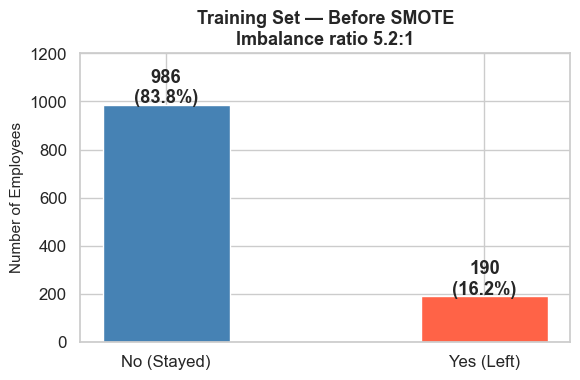

Class counts  →  No: 986,  Yes: 190
A classifier predicting "No" always scores 83.8% accuracy.


In [34]:
# Cell P4-D — Class distribution in training set (before SMOTE)
train_counts = y_train.value_counts().sort_index()
imbalance_ratio = train_counts[0] / train_counts[1]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['No (Stayed)', 'Yes (Left)'], train_counts.values,
              color=['steelblue', 'tomato'], edgecolor='white', width=0.4)
for bar, count in zip(bars, train_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8,
            f'{count}\n({count / len(y_train) * 100:.1f}%)',
            ha='center', fontweight='bold')
ax.set_title(f'Training Set — Before SMOTE\nImbalance ratio {imbalance_ratio:.1f}:1', fontweight='bold')
ax.set_ylabel('Number of Employees')
ax.set_ylim(0, max(train_counts.values) * 1.22)
plt.tight_layout()
plt.show()

print(f'Class counts  →  No: {train_counts[0]},  Yes: {train_counts[1]}')
print(f'A classifier predicting "No" always scores {train_counts[0] / len(y_train):.1%} accuracy.')

In [35]:
# Cell P4-E — Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Preserve DataFrame column names for SHAP / feature importance in later phases
X_train_smote = pd.DataFrame(X_train_smote, columns=X_train.columns)
y_train_smote = pd.Series(y_train_smote, name='Attrition')

smote_counts = y_train_smote.value_counts().sort_index()
synthetic_added = smote_counts[1] - y_train.value_counts()[1]

print(f'SMOTE applied (k_neighbors=5, random_state=42).')
print(f'X_train_smote : {X_train_smote.shape}')
print(f'y_train_smote : {y_train_smote.shape}')
print(f'\nClass distribution after SMOTE:')
print(f'  No  (0): {smote_counts[0]}  ({smote_counts[0] / len(y_train_smote) * 100:.1f}%)')
print(f'  Yes (1): {smote_counts[1]}  ({smote_counts[1] / len(y_train_smote) * 100:.1f}%)')
print(f'\nSynthetic minority examples added: {synthetic_added}')
print(f'X_test unchanged: {X_test.shape}')

SMOTE applied (k_neighbors=5, random_state=42).
X_train_smote : (1972, 76)
y_train_smote : (1972,)

Class distribution after SMOTE:
  No  (0): 986  (50.0%)
  Yes (1): 986  (50.0%)

Synthetic minority examples added: 796
X_test unchanged: (294, 76)


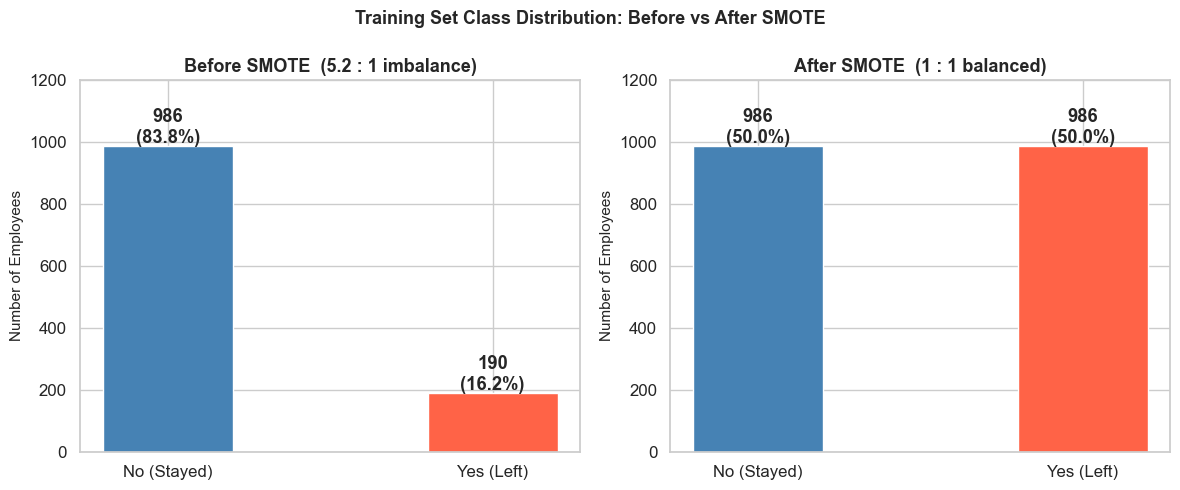

In [36]:
# Cell P4-F — Class distribution before vs after SMOTE (side-by-side)
labels = ['No (Stayed)', 'Yes (Left)']
before_counts = y_train.value_counts().sort_index().values
after_counts  = pd.Series(y_train_smote).value_counts().sort_index().values

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars0 = axes[0].bar(labels, before_counts, color=['steelblue', 'tomato'],
                    edgecolor='white', width=0.4)
for bar, count in zip(bars0, before_counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                 f'{count}\n({count / before_counts.sum() * 100:.1f}%)',
                 ha='center', fontweight='bold')
axes[0].set_title('Before SMOTE  (5.2 : 1 imbalance)', fontweight='bold')
axes[0].set_ylabel('Number of Employees')
axes[0].set_ylim(0, 1200)

bars1 = axes[1].bar(labels, after_counts, color=['steelblue', 'tomato'],
                    edgecolor='white', width=0.4)
for bar, count in zip(bars1, after_counts):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                 f'{count}\n({count / after_counts.sum() * 100:.1f}%)',
                 ha='center', fontweight='bold')
axes[1].set_title('After SMOTE  (1 : 1 balanced)', fontweight='bold')
axes[1].set_ylabel('Number of Employees')
axes[1].set_ylim(0, 1200)

plt.suptitle('Training Set Class Distribution: Before vs After SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Phase 4 — Summary

### Strategy

| Technique | Training Data | Use in Phase 5 |
|-----------|--------------|----------------|
| **SMOTE** | `X_train_smote` (1972, 76) / `y_train_smote` (1972,) — 50/50 balanced | Logistic Regression and other linear models |
| **`class_weight='balanced'`** | `X_train` / `y_train` (original, unmodified) | Pass as param to tree-based sklearn estimators |
| **Threshold tuning** | Applied post-training on predicted probabilities | Phase 6 — after model selection |

### Test set policy
`X_test` and `y_test` are **never resampled**. Evaluation always uses the original held-out distribution (16% attrition) to reflect real-world class frequencies.

### Priority metrics (Phase 5 onwards)
1. **Recall (Yes)** — catching leavers is the core business goal; false negatives are the costly error
2. **F1 (Yes)** — balances recall with precision to keep HR intervention lists actionable
3. **ROC-AUC** — threshold-independent discrimination quality
4. **PR-AUC** — more informative than ROC-AUC under class imbalance; treats minority class as positive

In [37]:
# Cell P5-IMPORTS — Phase 5 model imports
%pip install --quiet xgboost lightgbm

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

print(f'xgboost {xgb.__version__} | lightgbm {lgb.__version__}')
print('Phase 5 imports loaded.')

Note: you may need to restart the kernel to use updated packages.
xgboost 3.2.0 | lightgbm 4.6.0
Phase 5 imports loaded.



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Phase 5 — Modeling

Four binary classifiers trained in order of interpretability — default hyperparameters only. Tuning is Phase 6.

| Label | Model | Training Data | Imbalance Strategy |
|-------|-------|---------------|--------------------|
| **P5-LR** | Logistic Regression | `X_train_smote` / `y_train_smote` | SMOTE (50/50) |
| **P5-RF** | Random Forest | `X_train` / `y_train` | `class_weight='balanced'` |
| **P5-XGB** | XGBoost | `X_train` / `y_train` | `scale_pos_weight` |
| **P5-LGBM** | LightGBM | `X_train` / `y_train` | `is_unbalance=True` |

All models evaluated on the **original** `X_test` / `y_test` (294 samples, 16% attrition).

**Priority metrics:** Recall (Yes) → F1 (Yes) → ROC-AUC → PR-AUC

=== LR — Train (SMOTE) ===
              precision    recall  f1-score   support

 No (Stayed)      0.900     0.940     0.920       986
  Yes (Left)      0.937     0.896     0.916       986

    accuracy                          0.918      1972
   macro avg      0.919     0.918     0.918      1972
weighted avg      0.919     0.918     0.918      1972

ROC-AUC : 0.9711
PR-AUC  : 0.9771


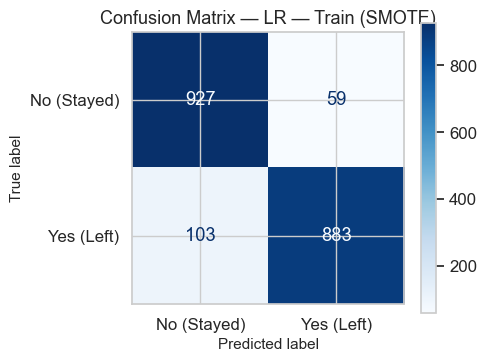

=== LR — Test ===
              precision    recall  f1-score   support

 No (Stayed)      0.902     0.931     0.916       247
  Yes (Left)      0.564     0.468     0.512        47

    accuracy                          0.857       294
   macro avg      0.733     0.700     0.714       294
weighted avg      0.848     0.857     0.852       294

ROC-AUC : 0.7953
PR-AUC  : 0.5475


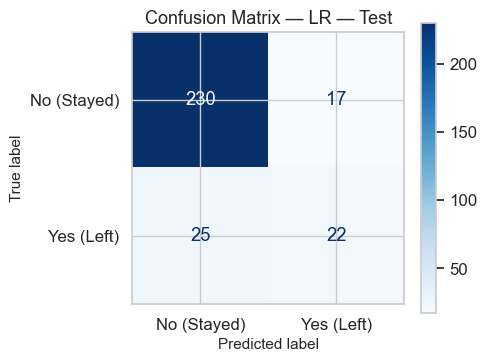

In [38]:
# Cell P5-LR — Logistic Regression (interpretable baseline)
# Trained on SMOTE-balanced data (50/50). No native class_weight needed.

lr = LogisticRegression(
    C=1.0,          # Default regularisation strength
    solver='lbfgs', # Efficient for medium-sized datasets, supports L2
    max_iter=1000,  # Default 100 often fails to converge on 76 scaled features
    random_state=42,
    n_jobs=-1
)

lr.fit(X_train_smote, y_train_smote)

evaluate_model(lr, X_train_smote, y_train_smote, label='LR — Train (SMOTE)')
evaluate_model(lr, X_test, y_test, label='LR — Test')

=== RF — Train ===
              precision    recall  f1-score   support

 No (Stayed)      1.000     0.992     0.996       986
  Yes (Left)      0.960     1.000     0.979       190

    accuracy                          0.993      1176
   macro avg      0.980     0.996     0.988      1176
weighted avg      0.993     0.993     0.993      1176

ROC-AUC : 1.0000
PR-AUC  : 1.0000


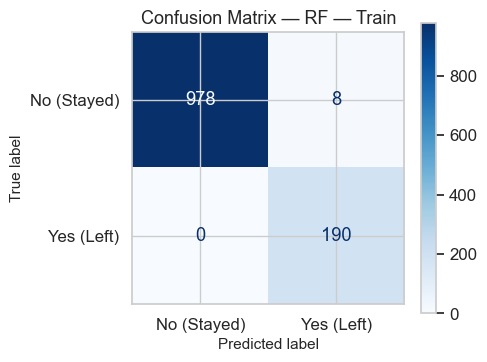

=== RF — Test ===
              precision    recall  f1-score   support

 No (Stayed)      0.896     0.911     0.904       247
  Yes (Left)      0.488     0.447     0.467        47

    accuracy                          0.837       294
   macro avg      0.692     0.679     0.685       294
weighted avg      0.831     0.837     0.834       294

ROC-AUC : 0.7818
PR-AUC  : 0.4460


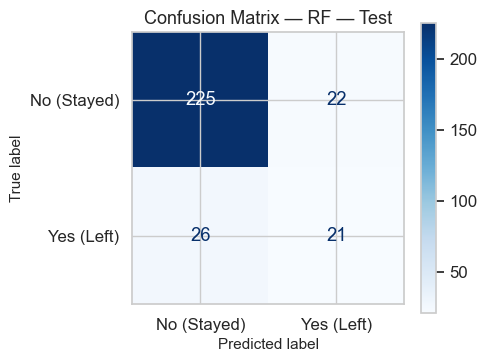

In [39]:
# Cell P5-RF — Random Forest (class_weight='balanced')
# Trained on original imbalanced data; class_weight handles the 5.2:1 ratio natively.

rf = RandomForestClassifier(
    n_estimators=300,        # Stable OOB estimates; negligible extra cost on this dataset size
    min_samples_leaf=2,      # Light regulariser — prevents single-sample minority leaves
    class_weight='balanced', # Weights: ~{No: 0.60, Yes: 3.10} from the 5.2:1 ratio
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

evaluate_model(rf, X_train, y_train, label='RF — Train')
evaluate_model(rf, X_test, y_test, label='RF — Test')

scale_pos_weight = 986 / 190 = 5.19
=== XGB — Train ===
              precision    recall  f1-score   support

 No (Stayed)      1.000     1.000     1.000       986
  Yes (Left)      1.000     1.000     1.000       190

    accuracy                          1.000      1176
   macro avg      1.000     1.000     1.000      1176
weighted avg      1.000     1.000     1.000      1176

ROC-AUC : 1.0000
PR-AUC  : 1.0000


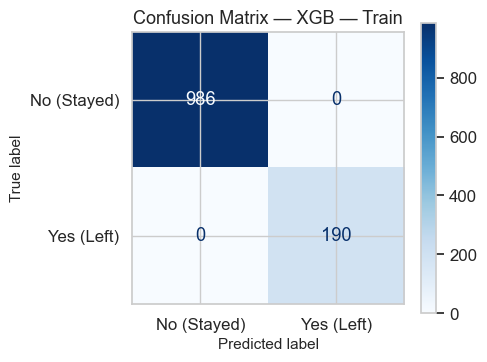

=== XGB — Test ===
              precision    recall  f1-score   support

 No (Stayed)      0.887     0.951     0.918       247
  Yes (Left)      0.586     0.362     0.447        47

    accuracy                          0.857       294
   macro avg      0.736     0.657     0.683       294
weighted avg      0.839     0.857     0.843       294

ROC-AUC : 0.7909
PR-AUC  : 0.5298


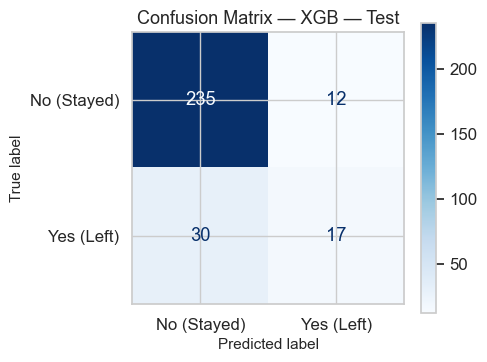

In [40]:
# Cell P5-XGB — XGBoost (scale_pos_weight for imbalance)

neg_count = int((y_train == 0).sum())
pos_count = int((y_train == 1).sum())
spw = neg_count / pos_count
print(f'scale_pos_weight = {neg_count} / {pos_count} = {spw:.2f}')

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,  # Upweights minority class by the imbalance ratio ~5.19
    eval_metric='logloss', # Suppresses default XGBoost warning
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

evaluate_model(xgb_model, X_train, y_train, label='XGB — Train')
evaluate_model(xgb_model, X_test, y_test, label='XGB — Test')

=== LGBM — Train ===
              precision    recall  f1-score   support

 No (Stayed)      1.000     1.000     1.000       986
  Yes (Left)      1.000     1.000     1.000       190

    accuracy                          1.000      1176
   macro avg      1.000     1.000     1.000      1176
weighted avg      1.000     1.000     1.000      1176

ROC-AUC : 1.0000
PR-AUC  : 1.0000


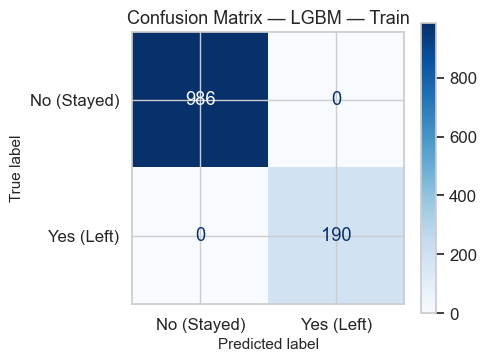

=== LGBM — Test ===
              precision    recall  f1-score   support

 No (Stayed)      0.876     0.972     0.921       247
  Yes (Left)      0.650     0.277     0.388        47

    accuracy                          0.861       294
   macro avg      0.763     0.624     0.655       294
weighted avg      0.840     0.861     0.836       294

ROC-AUC : 0.7966
PR-AUC  : 0.5373


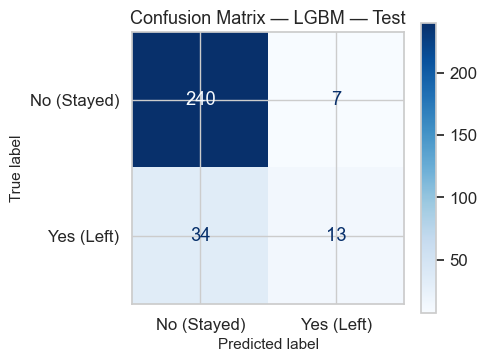

In [41]:
# Cell P5-LGBM — LightGBM (is_unbalance=True)

lgbm_model = lgb.LGBMClassifier(
    n_estimators=300,
    num_leaves=31,       # LightGBM default; governs complexity (leaf-wise growth)
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,   # LightGBM-native equivalent of class_weight='balanced'
    random_state=42,
    n_jobs=-1,
    verbose=-1           # Suppresses per-tree output (300 lines otherwise)
)

lgbm_model.fit(X_train, y_train)

evaluate_model(lgbm_model, X_train, y_train, label='LGBM — Train')
evaluate_model(lgbm_model, X_test, y_test, label='LGBM — Test')

In [42]:
# Cell P5-COMPARE — Test-set metrics for all 4 models

def get_metrics(model, X, y, name):
    y_pred  = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    report  = classification_report(y, y_pred, output_dict=True)
    return {
        'Model':            name,
        'Recall (Yes)':     round(report['1']['recall'],    3),
        'Precision (Yes)':  round(report['1']['precision'], 3),
        'F1 (Yes)':         round(report['1']['f1-score'],  3),
        'ROC-AUC':          round(roc_auc_score(y, y_proba), 3),
        'PR-AUC':           round(average_precision_score(y, y_proba), 3),
    }

results = pd.DataFrame([
    get_metrics(lr,         X_test, y_test, 'Logistic Regression'),
    get_metrics(rf,         X_test, y_test, 'Random Forest'),
    get_metrics(xgb_model,  X_test, y_test, 'XGBoost'),
    get_metrics(lgbm_model, X_test, y_test, 'LightGBM'),
]).set_index('Model')

styled = (
    results.style
    .highlight_max(axis=0, color='#c6efce')
    .highlight_min(axis=0, color='#ffc7ce')
    .format('{:.3f}')
    .set_caption('Phase 5 — Test Set Performance (X_test / y_test, 16% attrition)')
)

display(styled)

winner = results.sort_values(
    ['Recall (Yes)', 'F1 (Yes)', 'ROC-AUC', 'PR-AUC'], ascending=False
).index[0]
print(f'\nPhase 5 winner (priority metric hierarchy): {winner}')

,Recall (Yes),Precision (Yes),F1 (Yes),ROC-AUC,PR-AUC
Model,,,,,
Logistic Regression,0.468,0.564,0.512,0.795,0.547
Random Forest,0.447,0.488,0.467,0.782,0.446
XGBoost,0.362,0.586,0.447,0.791,0.530
LightGBM,0.277,0.650,0.388,0.797,0.537



Phase 5 winner (priority metric hierarchy): Logistic Regression


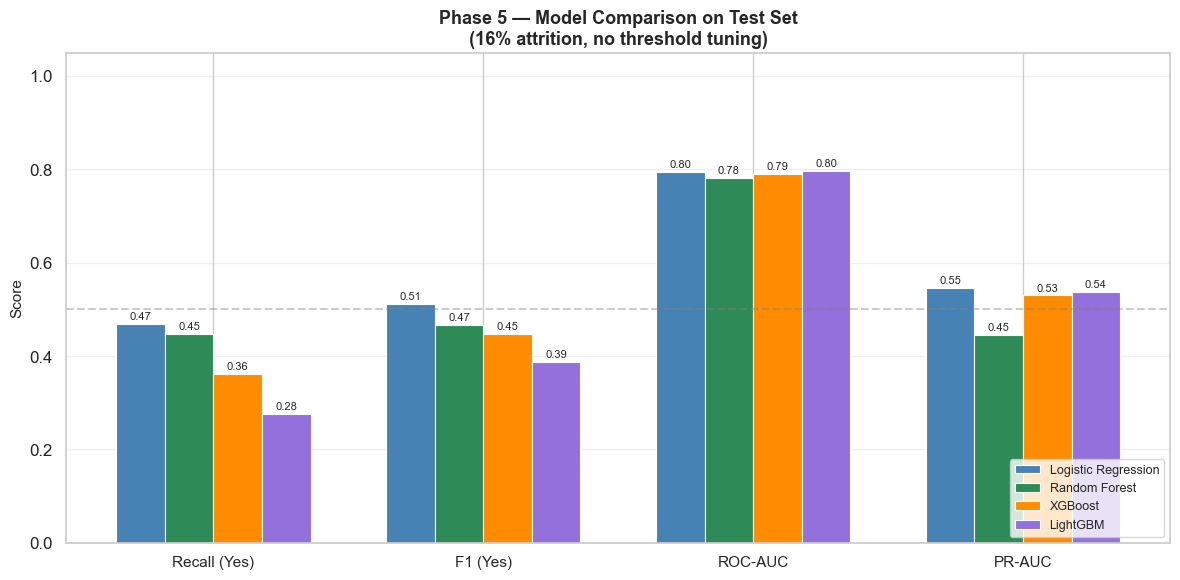

In [43]:
# Cell P5-COMPARE-PLOT — Grouped bar chart: 4 models x 4 metrics

metrics_to_plot = ['Recall (Yes)', 'F1 (Yes)', 'ROC-AUC', 'PR-AUC']
x = np.arange(len(metrics_to_plot))
bar_width = 0.18
colors = ['steelblue', 'seagreen', 'darkorange', 'mediumpurple']

fig, ax = plt.subplots(figsize=(12, 6))

for i, (model_name, row) in enumerate(results.iterrows()):
    offset = (i - 1.5) * bar_width
    bars = ax.bar(x + offset, row[metrics_to_plot].values,
                  width=bar_width, label=model_name,
                  color=colors[i], edgecolor='white', linewidth=0.8)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.2f}',
                ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_title('Phase 5 — Model Comparison on Test Set\n(16% attrition, no threshold tuning)',
             fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
# Cell P5-OVERFITTING — Train vs Test Recall (Yes) to surface overfitting

def get_recall_yes(model, X, y):
    y_pred = model.predict(X)
    report = classification_report(y, y_pred, output_dict=True)
    return round(report['1']['recall'], 3)

gap_df = pd.DataFrame({
    'Model':        ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM'],
    'Train Recall': [
        get_recall_yes(lr,         X_train_smote, y_train_smote),
        get_recall_yes(rf,         X_train,       y_train),
        get_recall_yes(xgb_model,  X_train,       y_train),
        get_recall_yes(lgbm_model, X_train,       y_train),
    ],
    'Test Recall':  [
        get_recall_yes(lr,         X_test, y_test),
        get_recall_yes(rf,         X_test, y_test),
        get_recall_yes(xgb_model,  X_test, y_test),
        get_recall_yes(lgbm_model, X_test, y_test),
    ],
}).set_index('Model')

gap_df['Gap'] = (gap_df['Train Recall'] - gap_df['Test Recall']).round(3)

print('=== Train vs Test Recall (Yes) — Overfitting Check ===')
print(gap_df.to_string())
print('\nGap > 0.15 in tree models = target for Phase 6 regularisation.')

=== Train vs Test Recall (Yes) — Overfitting Check ===
                     Train Recall  Test Recall  Gap
Model                                              
Logistic Regression          0.90         0.47 0.43
Random Forest                1.00         0.45 0.55
XGBoost                      1.00         0.36 0.64
LightGBM                     1.00         0.28 0.72

Gap > 0.15 in tree models = target for Phase 6 regularisation.


## Phase 5 — Modeling Summary

Four classifiers trained with default hyperparameters, evaluated on held-out test set (294 samples, 16.0% attrition). No threshold tuning — that is Phase 6.

### Training Configuration

| Model | Training Data | Imbalance Handling |
|-------|---------------|--------------------|
| Logistic Regression | X_train_smote (1,972 rows, 50/50) | SMOTE pre-balancing |
| Random Forest | X_train (1,176 rows, 16.2%) | class_weight='balanced' |
| XGBoost | X_train (1,176 rows, 16.2%) | scale_pos_weight ≈ 5.19 |
| LightGBM | X_train (1,176 rows, 16.2%) | is_unbalance=True |

### Key Observations

*(Fill in after running — read from the comparison table above.)*

### Phase 6 Direction

- **Winner** model proceeds to threshold tuning and GridSearchCV.
- Overfitting gap in tree models guides regularisation search space:
  - Random Forest: `max_depth`, `min_samples_leaf`
  - XGBoost: `max_depth`, `min_child_weight`, `gamma`
  - LightGBM: `num_leaves`, `min_child_samples`
- Threshold will be tuned to maximise Recall (Yes) while keeping Precision (Yes) above a business-viable floor.